In [1]:
%%latex
InteractiveShell.ast_node_interactivity = "all"

<IPython.core.display.Latex object>

In [2]:
from scipy.special import gamma
from scipy.integrate import quad
from cmath import sqrt as csqrt
# import spherical harmonics
from scipy.special import sph_harm
# multiple line output
from IPython.core.interactiveshell import InteractiveShell
import numpy as np
from functools import lru_cache
from collections import defaultdict
from decimal import Decimal
from functools import lru_cache
from sympy import S
from sympy.physics.wigner import wigner_3j

# Parameters

In [3]:
rp  = 1.0
q   = 60./100. # qr_+
iq  = 1j*q
params = {'rp': rp, 'q': q, 'iq': iq}

## Utilities

In [4]:
def poch(a,n):
    """
    Pochhammer symbol
    """
    if type(n) == int:
        return (-1)**n * gamma(1-a)/gamma(1-a-n)
    else:
        return gamma(a+n)/gamma(a)

In [5]:
# def complex conjugate of a function
def bar(f):
    """
    Calculate the complex conjugate of a function.
    """
    return np.conj(f)

# conformal weight h(l) for scalar field with charge q
def d2(l):
    return 0.25 + l*(l+1) - q**2

def h(l):
    d2 = 0.25 + l*(l+1) - q**2
    if d2 > 0:
        return 0.5 + csqrt(d2)
    else:
        return 0.5 - csqrt(d2)

h0 = h(0)

# QNM frequencies

In [6]:
def s(n, l):
    """
    qnm frequency in the variable s=-i\omega
    """
    return - (n + h(l) + iq) / 2.

def w(n, l):
    """
    qnm frequency in the variable s=-i\omega
    """
    return 1j * s(n, l)

In [7]:
from coupling_coefficients_stable import CouplingCoefficients 

In [8]:
# normalization factor for the near-zone radial functions s.t <R_nl, R_nl> = 1
def Anorm(n, l):
    Anorm_tmp = ( 1j * (-1.)**(h(l)+iq) * 2. * gamma(n+1.) * gamma(2*h(l)+n) * gamma(1-h(l)-n-iq)  ) / ( gamma(h(l)-iq) * poch(h(l)+iq,n) )
    return csqrt(Anorm_tmp)

In [9]:
Anorm(3,6)

(5.2589227117087365+16.031987143493794j)

# dynamical system

In [10]:
from scipy.integrate import solve_ivp

Configure evolution parameters

In [11]:
eps = 0.02
T = 800.0  #evolution time

In [12]:
modes_mixed = [
    {"n": 1, "l": 1, "m": 1},
    {"n": 2, "l": 1, "m": -1},
    {"n": 7, "l": 1, "m": 1},
    {"n": 11, "l": 1, "m": 0},
]

modes_mixed2 = [
    {"n": 0, "l": 1, "m": 0},
    {"n": 0, "l": 0, "m": 0},
    {"n": 1, "l": 1, "m": 0},
    {"n": 1, "l": 2, "m": 0},
]

modes_nmax8_sph = [
    {"n": n, "l": 0, "m": 0}
    for n in range(0, 8)
]

modes_12 = [
    {"n": 0, "l": 1, "m": -1},
    {"n": 0, "l": 2, "m":  0},
    {"n": 1, "l": 2, "m":  2},
    {"n": 2, "l": 1, "m":  1},
    {"n": 1, "l": 1, "m": -1},
    {"n": 1, "l": 1, "m":  0},
    {"n": 1, "l": 1, "m":  1},
   # {"n": 2, "l": 1, "m": -1},
    {"n": 2, "l": 1, "m":  0},
    {"n": 2, "l": 1, "m":  1},
]


In [13]:
modes = modes_12

## Initial Data

In [14]:
# initial data
def make_A0_from_powers(powers, phases=None, *, total_power=1.0, N=None):
    powers = np.asarray(powers, dtype=float)

    if np.any(powers < 0):
        raise ValueError("powers must be nonnegative")

    if np.sum(powers) <= 0:
        raise ValueError("powers must have positive total")

    powers = total_power * powers / np.sum(powers)

    if phases is None:
        phases = np.zeros_like(powers)
    else:
        phases = np.asarray(phases, dtype=float)

    if len(phases) != len(powers):
        raise ValueError(
            f"phase/power length mismatch: len(phases)={len(phases)}, "
            f"len(powers)={len(powers)}"
        )

    if N is not None and len(powers) != N:
        raise ValueError(
            f"A0 length mismatch: got len(A0)={len(powers)}, expected N={N}"
        )

    return np.sqrt(powers) * np.exp(1j * phases)

# Optional: normalize total action to 1
#A0 = A0 / np.sqrt(np.sum(np.abs(A0)**2))

def make_random_A0(
    modes,
    power_distribution="random",
    total_power=1.0,
    random_phases=True,
    seed=None,
):
    """
    Create random complex initial amplitudes A0 for a list of modes. Here power is defined as
      |A0|^2, so the total power is sum of |A0|^2 across modes.

    Parameters
    ----------
    modes : list of dict
        Example:
        [
            {"n": 0, "l": 1, "m": 0},
            {"n": 0, "l": 0, "m": 0},
            ...
        ]

    power_distribution : str
        "random"  -> random normalized powers
        "uniform" -> equal power in each mode

    total_power : float
        Total power of the state (sum of powers across modes).

    random_phases : bool
        If True, assign random phases in [0, 2π).

    seed : int or None
        RNG seed for reproducibility.

    Returns
    -------
    A0 : np.ndarray (complex)
        Complex amplitudes for each mode.

    powers : np.ndarray
        Normalized mode powers.

    phases : np.ndarray
        Phases used.
    """

    rng = np.random.default_rng(seed)

    N = len(modes)

    # --- powers ---
    if power_distribution == "random":
        powers = rng.random(N)
        powers /= np.sum(powers)

    elif power_distribution == "uniform":
        powers = np.ones(N) / N

    else:
        raise ValueError("power_distribution must be 'random' or 'uniform'")

    powers *= total_power

    # --- phases ---
    if random_phases:
        phases = rng.uniform(0, 2*np.pi, N)
    else:
        phases = np.zeros(N)

    # --- amplitudes ---
    A0 = np.sqrt(powers) * np.exp(1j * phases)

    return A0, powers, phases




def validate_dynamics_inputs(A0, C, mask=None, omega_arr=None, name=""):
    A0 = np.asarray(A0, dtype=complex)
    N = len(A0)

    if C.shape != (N, N, N, N):
        raise ValueError(
            f"{name} C/A0 mismatch: C.shape={C.shape}, but len(A0)={N}. "
            f"Expected C.shape == ({N},{N},{N},{N})."
        )

    if mask is not None and np.shape(mask) != (N, N, N, N):
        raise ValueError(
            f"{name} mask/A0 mismatch: mask.shape={np.shape(mask)}, "
            f"but len(A0)={N}."
        )

    if omega_arr is not None and len(omega_arr) != N:
        raise ValueError(
            f"{name} omega_arr/A0 mismatch: len(omega_arr)={len(omega_arr)}, "
            f"but len(A0)={N}."
        )

    return A0

In [16]:
def omega_mode(J):
    # J is a dictionary with keys "n", "l" , and "m"
    return w(J["n"], J["l"])



In [17]:
Coeffs = CouplingCoefficients(q, rp)

In [18]:
Ctensor = Coeffs.build_coupling_tensor(modes, alpha=1)

## Utilities

In [31]:
def mode_label(k):
    return f"n={k['n']}, l={k['l']}, m={k.get('m', 0)}"


def detuning_notes(modes, omega_arr, lam, i, j, k):
    return omega_arr[lam] + omega_arr[k] - omega_arr[i] - omega_arr[j]


def omega_shift_notes(A0, C):
    """
    omega_shift[lam] =
        sum_q (C[lam,q,lam,q] + C[lam,lam,q,q]) |A_q|^2.
    """

    N = len(A0)
    shift = np.zeros(N, dtype=complex)

    for lam in range(N):
        for q in range(N):
            shift[lam] += (
                C[lam, q, lam, q]
                + C[lam, lam, q, q]
            ) * abs(A0[q])**2

    return shift

def analyze_mode_set(modes, omega_arr, C=None, detuning_tol=1e-8, coupling_tol=1e-14):
    N = len(modes)

    print("Modes:")
    for a, mode in enumerate(modes):
        print(a, mode_label(mode), "omega =", omega_arr[a])

    print("\nActive angular/resonant quartets:")

    count_by_mode = np.zeros(N, dtype=int)

    quartets = []

    for lam in range(N):
        for i in range(N):
            for j in range(N):
                for k in range(N):

                    # magnetic selection
                    m_lam = modes[lam].get("m", 0)
                    m_i = modes[i].get("m", 0)
                    m_j = modes[j].get("m", 0)
                    m_k = modes[k].get("m", 0)

                    if m_i + m_j != m_k + m_lam:
                        continue

                    Om = detuning_notes(modes, omega_arr, lam, i, j, k)

                    if abs(np.real(Om)) > detuning_tol:
                        continue

                    if C is not None and abs(C[lam, i, j, k]) < coupling_tol:
                        continue

                    quartets.append((lam, i, j, k, Om))

                    count_by_mode[lam] += 1
                    count_by_mode[i] += 1
                    count_by_mode[j] += 1
                    count_by_mode[k] += 1

    print("number of selected quartets =", len(quartets))

    print("\nParticipation counts:")
    for a, c in enumerate(count_by_mode):
        print(a, mode_label(modes[a]), c)

    return quartets, count_by_mode

In [20]:
def hermitian_adjoint_notes(C):
    """
    Cdag[lam,i,j,k] = conjugate(C[i,lam,k,j])
    """
    return np.conjugate(np.transpose(C, (1, 0, 3, 2)))


def coupling_hermitian_defect(C, mask=None):
    if mask is None:
        mask = np.ones_like(C, dtype=bool)

    Cdag = hermitian_adjoint_notes(C)

    CH = 0.5 * (C + Cdag)
    CA = 0.5 * (C - Cdag)

    norm_H = np.linalg.norm(CH[mask])
    norm_A = np.linalg.norm(CA[mask])

    return norm_A / norm_H, norm_H, norm_A

# Config mode choices

In [22]:
# 1. choose modes 
modes = modes_12

# 2. build omega and C from those modes
omega_arr = np.array([omega_mode(k) for k in modes], dtype=complex)

C = Coeffs.build_C_notes(modes, alpha=1.0)

# 3. split / mask
Cdag = np.conjugate(np.transpose(C, (1, 0, 3, 2)))
C_H = 0.5 * (C + Cdag)
C_A = 0.5 * (C - Cdag)
mask_H = Coeffs.build_nondiag_mask_notes(len(modes))

# 4. make A0 with exactly len(modes) entries
A0, powers0, phases0 = make_random_A0(
    modes,
    power_distribution="random",
    total_power=1.0,
    random_phases=True,
    seed=42,
)

validate_dynamics_inputs(A0, C_H, mask=mask_H, omega_arr=omega_arr, name="main")

array([-0.35659488+0.11490945j, -0.19415681+0.20468952j,
        0.35356245-0.17523776j, -0.21996757-0.27944304j,
        0.05768859-0.11726875j, -0.39433289+0.14642306j,
        0.0529538 +0.36774396j, -0.35558197-0.12697046j,
        0.1403384 +0.05949559j])

# Interaction Picture Evolution

The system $$ia_\lambda = \omega_\lambda a_\lambda + \sum_{123} c^{12}_{\lambda,3} a_1 a_2 \bar{a}_3$$

still contains the fast time dynamics so we make the substition $$a_\lambda(t) = \epsilon A_\lambda(t) e^{-i \omega_\lambda t}$$

where $$ i \dot
{A}
_\lambda
    = 2 \epsilon ^ 2 \sum_{123} c ^ {12}_{\lambda,3} A_1 A_2 \bar{A}_3 e^{i (\omega_\lambda + \omega_3 - \omega_1 - \omega_2) t}$$

    note that in sec 8.1 of my notes I chose the convention with the barred slot last position for the coupling, but here we are using the convention with the barred slot in the second position, so we have to write a wrapper to match the paper's convention for the coupling coefficients.

In [40]:

def rhs_A_notes(t, A, eps, C, Omega, mask=None, phase_mode="exact"):
    """
    Notes convention:

        i A_lam' =
            eps^2 sum_{i,j,k}
            C[lam,i,j,k] A_i A_j bar(A_k)
            exp(i Omega[lam,i,j,k] t).
    """

    if mask is None:
        mask = 1.0

    if phase_mode == "exact":
        phase = np.exp(1j * Omega * t)
    elif phase_mode == "real":
        phase = np.exp(1j * np.real(Omega) * t)
    elif phase_mode == "resonant":
        phase = 1.0
    else:
        raise ValueError("phase_mode must be 'exact', 'real', or 'resonant'.")

    Ceff = C * mask * phase

    nonlinear = np.einsum(
        "lijk,i,j,k->l",
        Ceff,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    return -1j * eps**2 * nonlinear


def integrate_A_notes(
    A0,
    tmax,
    eps,
    omega_arr,
    C,
    nout=2000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
):
    A0 = validate_dynamics_inputs(
        A0,
        C,
        omega_arr=omega_arr,
        name="full notes evolution",
    )

    N = len(A0)

    if include_frequency_shift:
        omega_tilde = omega_arr + eps**2 * omega_shift_notes(A0, C)
    else:
        omega_tilde = omega_arr.copy()

    real_phase = phase_mode == "real"
    Omega = Coeffs.build_Omega_notes(omega_tilde, real_phase=real_phase)

    mask = np.ones((N, N, N, N), dtype=bool)

    if remove_diag:
        mask &= Coeffs.build_nondiag_mask_notes(N)

    t_eval = np.linspace(0.0, tmax, nout)

    sol = solve_ivp(
        rhs_A_notes,
        (0.0, tmax),
        A0,
        t_eval=t_eval,
        args=(eps, C, Omega, mask, phase_mode),
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )

    return sol, omega_tilde, Omega, mask

In [41]:
def inspect_solution(sol, modes):
    A = sol.y.T
    t = sol.t

    print("success:", sol.success)
    print("message:", sol.message)
    print("nfev:", sol.nfev)
    print("t range:", t[0], t[-1])
    print("A shape:", A.shape)

    amps = np.abs(A)
    powers = amps**2

    print("\ninitial amplitudes:")
    for a, k in zip(A[0], modes):
        print(mode_label(k), a, " |A|=", abs(a))

    print("\nfinal amplitudes:")
    for a, k in zip(A[-1], modes):
        print(mode_label(k), a, " |A|=", abs(a))

    print("\nmax |A| by mode:")
    for j, k in enumerate(modes):
        print(mode_label(k), np.max(amps[:, j]))

    print("\ntotal power:")
    print("initial:", np.sum(powers[0]))
    print("final:  ", np.sum(powers[-1]))
    print("relative drift:", (np.sum(powers[-1]) - np.sum(powers[0])) / np.sum(powers[0]))

    return t, A, amps, powers

In [42]:
# evolve the system and get the solution, shifted frequencies, Omega tensor, and mask
sol, omega_tilde, Omega, mask = integrate_A_notes(
    A0,
    T,
    eps,
    omega_arr,
    C,
    nout=1000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

### analyze the mode set to find active quartets

In [43]:
#omega_arr = np.array([omega_mode(k) for k in modes], dtype=complex)
#C = build_C_notes(modes, alpha=1.0)

quartets, counts = analyze_mode_set(
    modes,
    omega_arr,
    C=C,
    detuning_tol=1e-8,
    coupling_tol=1e-12,
)

Modes:
0 n=0, l=1, m=-1 omega = (0.3-0.937386354243376j)
1 n=0, l=2, m=0 omega = (0.3-1.4634661099511597j)
2 n=1, l=2, m=2 omega = (0.3-1.9634661099511597j)
3 n=2, l=1, m=1 omega = (0.3-1.937386354243376j)
4 n=1, l=1, m=-1 omega = (0.3-1.437386354243376j)
5 n=1, l=1, m=0 omega = (0.3-1.437386354243376j)
6 n=1, l=1, m=1 omega = (0.3-1.437386354243376j)
7 n=2, l=1, m=0 omega = (0.3-1.937386354243376j)
8 n=2, l=1, m=1 omega = (0.3-1.937386354243376j)

Active angular/resonant quartets:
number of selected quartets = 819

Participation counts:
0 n=0, l=1, m=-1 356
1 n=0, l=2, m=0 296
2 n=1, l=2, m=2 232
3 n=2, l=1, m=1 428
4 n=1, l=1, m=-1 356
5 n=1, l=1, m=0 376
6 n=1, l=1, m=1 428
7 n=2, l=1, m=0 376
8 n=2, l=1, m=1 428


In [44]:
t, A, amps, powers = inspect_solution(sol, modes)

success: True
message: The solver successfully reached the end of the integration interval.
nfev: 92
t range: 0.0 800.0
A shape: (1000, 9)

initial amplitudes:
n=0, l=1, m=-1 (-0.35659488018009167+0.11490944684317812j)  |A|= 0.37465195788152383
n=0, l=2, m=0 (-0.1941568108908725+0.20468951622416695j)  |A|= 0.28212526520571946
n=1, l=2, m=2 (0.35356244617507143-0.1752377602604538j)  |A|= 0.39460698925183846
n=2, l=1, m=1 (-0.2199675710805575-0.2794430377358551j)  |A|= 0.35563203408315547
n=1, l=1, m=-1 (0.05768858647622974-0.11726875243419937j)  |A|= 0.13069021886544907
n=1, l=1, m=0 (-0.3943328879658337+0.14642306089677676j)  |A|= 0.42064015416250494
n=1, l=1, m=1 (0.0529537994395299+0.36774396208664917j)  |A|= 0.37153697867946983
n=2, l=1, m=0 (-0.3555819673330322-0.12697046280970414j)  |A|= 0.37757123025800055
n=2, l=1, m=1 (0.14033840367722228+0.059495587762330514j)  |A|= 0.1524289752962217

final amplitudes:
n=0, l=1, m=-1 (-0.3490820708772584+0.18374780111176667j)  |A|= 0.39448896

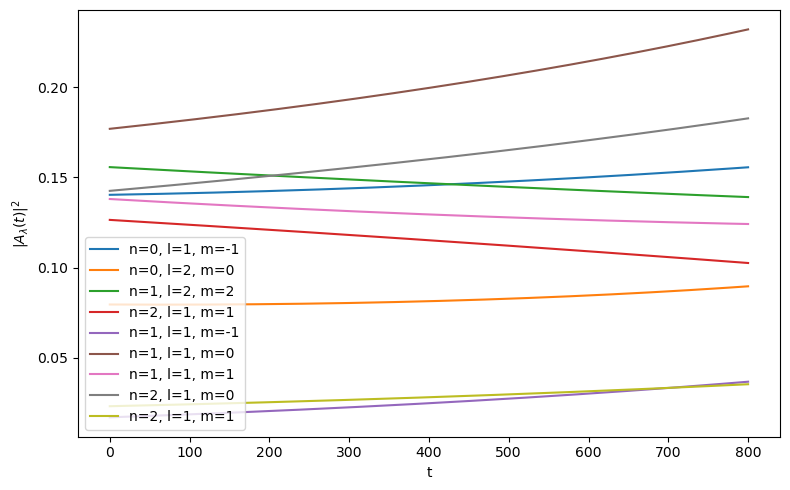

In [45]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.plot(t, powers[:, j], label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda(t)|^2$")
plt.legend()
plt.tight_layout()
plt.show()

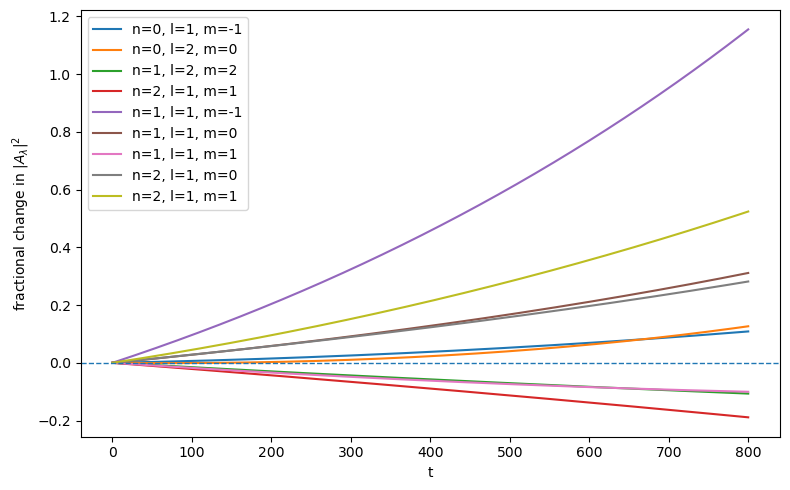

In [46]:
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    p0 = powers[0, j]
    if p0 != 0:
        plt.plot(t, (powers[:, j] - p0) / p0, label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"fractional change in $|A_\lambda|^2$")
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend()
plt.tight_layout()
plt.show()

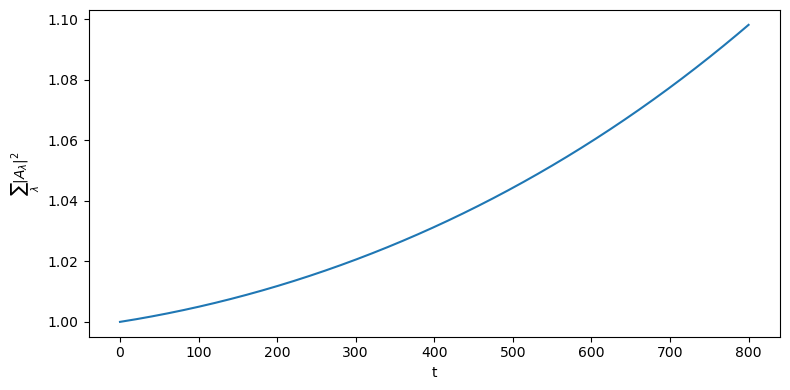

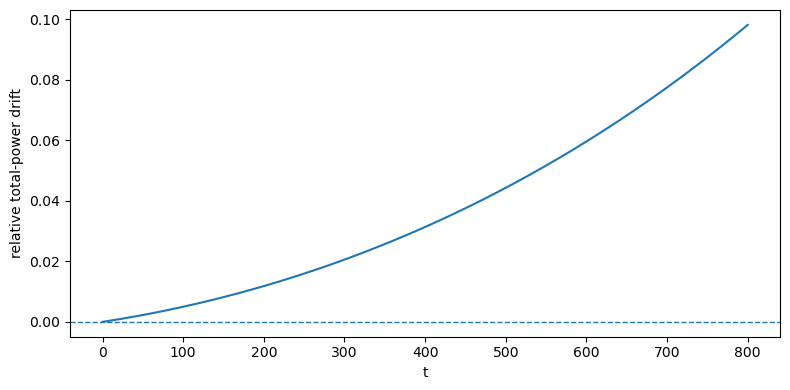

In [47]:
total_power = np.sum(powers, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(t, total_power)
plt.xlabel("t")
plt.ylabel(r"$\sum_\lambda |A_\lambda|^2$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(t, (total_power - total_power[0]) / total_power[0])
plt.xlabel("t")
plt.ylabel("relative total-power drift")
plt.axhline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [48]:
# check hermitian defect of the coupling tensor 
eta, norm_H, norm_A = coupling_hermitian_defect(C, mask)

print("||C_antiHerm|| / ||C_Herm|| =", eta)
print("||C_Herm|| =", norm_H)
print("||C_antiHerm|| =", norm_A)

||C_antiHerm|| / ||C_Herm|| = 1.0006943463332785
||C_Herm|| = 9.714864002930488
||C_antiHerm|| = 9.721609483129223


In [49]:
def total_action(A):
    return np.sum(np.abs(A)**2)


def Ndot_notes(t, A, eps, C, Omega, mask=None, phase_mode="real"):
    if mask is None:
        mask = 1.0

    if phase_mode == "exact":
        phase = np.exp(1j * Omega * t)
    elif phase_mode == "real":
        phase = np.exp(1j * np.real(Omega) * t)
    elif phase_mode == "resonant":
        phase = 1.0
    else:
        raise ValueError("phase_mode must be 'exact', 'real', or 'resonant'.")

    F = np.einsum(
        "lijk,i,j,k->l",
        C * mask * phase,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    Z = np.vdot(A, F)  # sum_l conjugate(A_l) F_l

    return 2 * eps**2 * np.imag(Z)

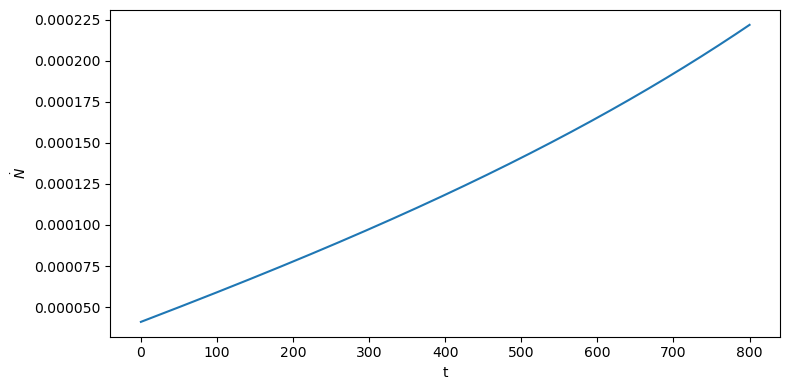

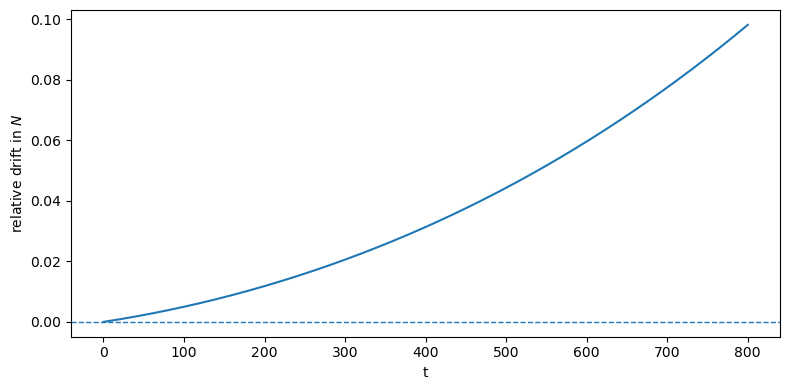

In [50]:
A_of_t = sol.y.T
Ndots = np.array([
    Ndot_notes(ti, Ai, eps, C, Omega, mask, phase_mode="real")
    for ti, Ai in zip(sol.t, A_of_t)
])

Ntot = np.sum(np.abs(A_of_t)**2, axis=1)

plt.figure(figsize=(8,4))
plt.plot(sol.t, Ndots)
plt.xlabel("t")
plt.ylabel(r"$\dot N$")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(sol.t, (Ntot - Ntot[0]) / Ntot[0])
plt.xlabel("t")
plt.ylabel(r"relative drift in $N$")
plt.axhline(0, linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [51]:
Ntot = np.sum(np.abs(sol.y.T)**2, axis=1)
relN = (Ntot - Ntot[0]) / Ntot[0]

slope, intercept = np.polyfit(sol.t, relN, 1)

print("relative drift slope =", slope)
print("relative drift at final time =", relN[-1])

relative drift slope = 0.00012097299181522432
relative drift at final time = 0.09815407233465481


In [52]:
Cdag = np.conjugate(np.transpose(C, (1, 0, 3, 2)))
C_H = 0.5 * (C + Cdag)
C_A = 0.5 * (C - Cdag)

print("relative anti-Hermitian defect =", np.linalg.norm(C_A[mask]) / np.linalg.norm(C_H[mask]))

relative anti-Hermitian defect = 1.0006943463332785


In [69]:
eps_values = [0.025, 0.05, 0.1]
drifts = []

for ep in eps_values:
    sol_ep, omega_tilde_ep, Omega_ep, mask_ep = integrate_A_notes(
        A0,
        T,
        ep,
        omega_arr,
        C,
        nout=1000,
        remove_diag=True,
        include_frequency_shift=True,
        phase_mode="real",
    )

    P_ep = np.abs(sol_ep.y.T)**2
    N_ep = np.sum(P_ep, axis=1)
    drifts.append((N_ep[-1] - N_ep[0]) / N_ep[0])

for ep, drift in zip(eps_values, drifts):
    print(ep, drift, "drift/eps^2 =", drift / ep**2)

0.025 0.23672159778176277 drift/eps^2 = 378.75455645082036
0.05 1741.1418120874284 drift/eps^2 = 696456.7248349712
0.1 720.0709590089831 drift/eps^2 = 72007.09590089829


In [54]:
def physical_from_A_solution(sol, omega_arr, eps=1.0, include_eps=False):
    """
    Reconstruct physical/softened amplitudes

        a_lam(t) = eps A_lam(t) exp(-i omega_lam t).

    If include_eps=False, returns A_lam exp(-i omega_lam t),
    matching Mathematica's genInterpsWithSoftener convention up to eps.
    """

    t = sol.t
    A = sol.y.T

    soft = np.exp(-1j * omega_arr[None, :] * t[:, None])

    if include_eps:
        return t, eps * A * soft

    return t, A * soft

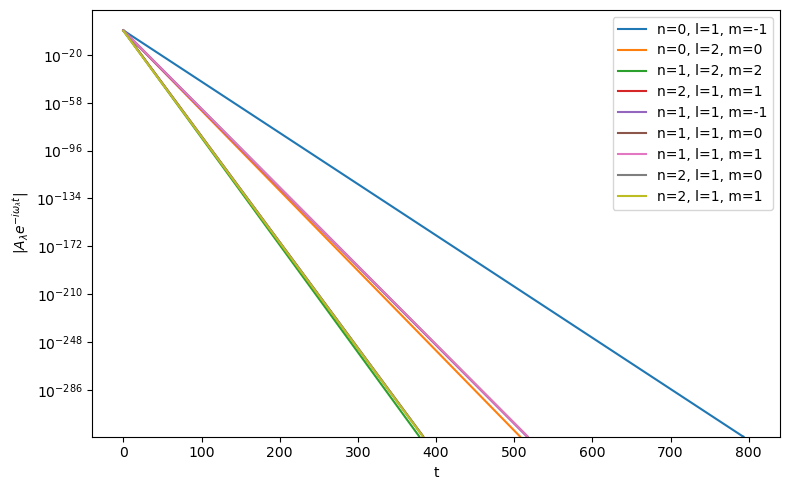

In [55]:
t, a_phys = physical_from_A_solution(sol, omega_arr, eps=eps, include_eps=False)

plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.semilogy(t, np.abs(a_phys[:, j]), label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda e^{-i\omega_\lambda t}|$")
plt.legend()
plt.tight_layout()
plt.show()

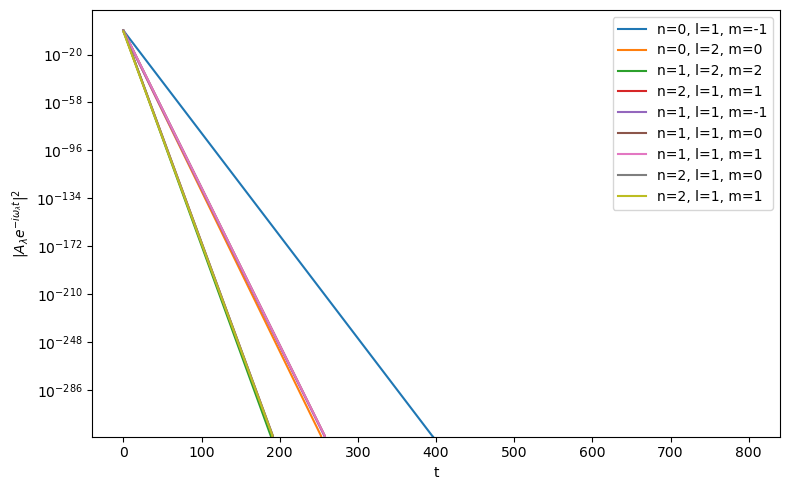

Skipping perturbative final-time comparison; A_num_T and A_pert_T are not defined.


In [56]:
plt.figure(figsize=(8, 5))

for j, k in enumerate(modes):
    plt.semilogy(t, np.abs(a_phys[:, j])**2, label=mode_label(k))

plt.xlabel("t")
plt.ylabel(r"$|A_\lambda e^{-i\omega_\lambda t}|^2$")
plt.legend()
plt.tight_layout()
plt.show()

if "A_num_T" in globals() and "A_pert_T" in globals():
    print("modewise comparison at final time:")

    for j, k in enumerate(modes):
        print()
        print(mode_label(k))
        print("  numerical:", A_num_T[j])
        print("  pert:     ", A_pert_T[j])
        print("  diff:     ", A_num_T[j] - A_pert_T[j])
        if abs(A_num_T[j]) > 0:
            print("  rel diff: ", abs(A_num_T[j] - A_pert_T[j]) / abs(A_num_T[j]))
else:
    print("Skipping perturbative final-time comparison; A_num_T and A_pert_T are not defined.")


In [57]:
Cdag = np.conjugate(np.transpose(C, (1, 0, 3, 2)))
C_H = 0.5 * (C + Cdag)
C_A = 0.5 * (C - Cdag)

sol_H, omega_tilde_H, Omega_H, mask_H = integrate_A_notes(
    A0,
    T,
    0.05,
    omega_arr,
    C_H,
    nout=1000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

P_H = np.abs(sol_H.y.T)**2
N_H = np.sum(P_H, axis=1)

print("Hermitian projected drift =",
      (N_H[-1] - N_H[0]) / N_H[0])

Hermitian projected drift = -3.164801753996472e-12


In [58]:
shift = omega_shift_notes(A0, C)

print("frequency-shift real part:")
print(np.real(shift))

print("nonlinear damping/growth from imaginary part:")
print(np.imag(shift))

frequency-shift real part:
[-0.22026719 -0.20540137  0.05611403  0.03269475  0.02629785  0.06908781
  0.02629785  0.05984224  0.03269475]
nonlinear damping/growth from imaginary part:
[ 0.22269248  0.42505234 -0.11526722 -0.03278358 -0.02626697 -0.06997579
 -0.02626697 -0.06055391 -0.03278358]


In [59]:
Tlong = 80000.0
eps_sec = 0.05

sol_sec, omega_tilde_sec, Omega_sec, mask_sec = integrate_A_notes(
    A0,
    Tlong,
    eps_sec,
    omega_arr,
    C_H,
    nout=20000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

A_sec = sol_sec.y.T
t_sec = sol_sec.t

In [60]:
P_sec = np.abs(A_sec)**2
N_sec = np.sum(P_sec, axis=1)

print("relative N drift =", (N_sec[-1] - N_sec[0]) / N_sec[0])

relative N drift = -3.2859148735298055e-10


In [61]:
Tlong = 8e4
eps_sec = 0.05

sol_sec, omega_tilde_sec, Omega_sec, mask_sec = integrate_A_notes(
    A0,
    Tlong,
    eps_sec,
    omega_arr,
    C_H,
    nout=20000,
    remove_diag=True,
    include_frequency_shift=True,
    phase_mode="real",
)

A_sec = sol_sec.y.T
t_sec = sol_sec.t

In [62]:
P_sec = np.abs(A_sec)**2
N_sec = np.sum(P_sec, axis=1)

print("relative N drift =", (N_sec[-1] - N_sec[0]) / N_sec[0])

relative N drift = -3.2859148735298055e-10


In [63]:
t_sec

array([0.00000000e+00, 4.00020001e+00, 8.00040002e+00, ...,
       7.99919996e+04, 7.99959998e+04, 8.00000000e+04])

In [64]:
# nine modes with onnly four initially populated,
#  to test energy transfer and Hermitian vs non-Hermitian effects
powers_balanced = np.zeros(len(modes))
phases_balanced = np.zeros(len(modes))

powers_balanced[:4] = [0.40, 0.30, 0.20, 0.10]
phases_balanced[:4] = [0.0, 0.7, 1.8, -0.4]

A0_balanced = make_A0_from_powers(
    powers_balanced,
    phases=phases_balanced,
    N=len(modes),
)

## Poincare Sections

In [65]:
import numpy as np
import matplotlib.pyplot as plt

def wrap_angle(x):
    return (x + np.pi) % (2*np.pi) - np.pi


def normalized_powers_from_A(A):
    P = np.abs(A)**2
    N = np.sum(P, axis=1)
    return P / N[:, None]


def phase_combo(A, inds=(0, 1, 2, 3)):
    """
    Resonant phase combination

        phi = theta_i + theta_j - theta_k - theta_l.

    For four modes, a useful default is theta0 + theta1 - theta2 - theta3.
    """
    i, j, k, l = inds
    th = np.angle(A)
    return wrap_angle(th[:, i] + th[:, j] - th[:, k] - th[:, l])

In [66]:
def poincare_crossings(t, A, phase_inds=(0, 1, 2, 3), direction="positive"):
    p = normalized_powers_from_A(A)
    phi = phase_combo(A, inds=phase_inds)

    pts = []
    times = []
    indices = []

    for n in range(1, len(t)):
        phi0 = phi[n - 1]
        phi1 = phi[n]

        if direction == "positive":
            crossed = (phi0 < 0) and (phi1 >= 0)
        elif direction == "negative":
            crossed = (phi0 > 0) and (phi1 <= 0)
        elif direction == "either":
            crossed = phi0 * phi1 <= 0 and abs(phi1 - phi0) > 1e-14
        else:
            raise ValueError("direction must be 'positive', 'negative', or 'either'.")

        if crossed:
            denom = phi1 - phi0
            if abs(denom) < 1e-14:
                continue

            frac = -phi0 / denom

            p_cross = p[n - 1] + frac * (p[n] - p[n - 1])
            t_cross = t[n - 1] + frac * (t[n] - t[n - 1])

            pts.append(p_cross)
            times.append(t_cross)
            indices.append(n)

    Nmode = A.shape[1]

    return (
        np.asarray(times),
        np.asarray(pts).reshape((-1, Nmode)),
        np.asarray(indices),
    )

phi min = -3.1412100640507585
phi max = 3.141513137738283
phi initial = 1.5742762890764475
phi final = 2.3734834432451803


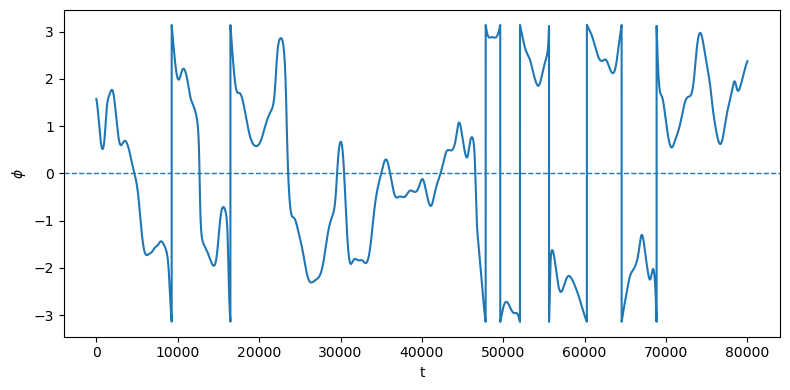

In [67]:
phi = phase_combo(A_sec, inds=(0, 1, 2, 3))

print("phi min =", np.min(phi))
print("phi max =", np.max(phi))
print("phi initial =", phi[0])
print("phi final =", phi[-1])

plt.figure(figsize=(8,4))
plt.plot(t_sec, phi)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("t")
plt.ylabel(r"$\phi$")
plt.tight_layout()
plt.show()

In [70]:
def poincare_crossings_level(t, A, phase_inds=(0, 1, 2, 3), level=None, direction="positive"):
    p = normalized_powers_from_A(A)
    phi_raw = phase_combo(A, inds=phase_inds)

    if level is None:
        level = np.mean(phi_raw)

    phi = wrap_angle(phi_raw - level)

    pts = []
    times = []
    indices = []

    for n in range(1, len(t)):
        phi0 = phi[n - 1]
        phi1 = phi[n]

        if direction == "positive":
            crossed = (phi0 < 0) and (phi1 >= 0)
        elif direction == "negative":
            crossed = (phi0 > 0) and (phi1 <= 0)
        elif direction == "either":
            crossed = phi0 * phi1 <= 0 and abs(phi1 - phi0) > 1e-14
        else:
            raise ValueError("direction must be 'positive', 'negative', or 'either'.")

        if crossed:
            denom = phi1 - phi0
            if abs(denom) < 1e-14:
                continue

            frac = -phi0 / denom
            p_cross = p[n - 1] + frac * (p[n] - p[n - 1])
            t_cross = t[n - 1] + frac * (t[n] - t[n - 1])

            pts.append(p_cross)
            times.append(t_cross)
            indices.append(n)

    Nmode = A.shape[1]

    return (
        np.asarray(times),
        np.asarray(pts).reshape((-1, Nmode)),
        np.asarray(indices),
        level,
    )

In [71]:
def nonlinear_rate_diagnostic(A0, C, mask=None, zero_tol=1e-14):
    if mask is None:
        mask = 1.0

    F = np.einsum(
        "lijk,i,j,k->l",
        C * mask,
        A0,
        A0,
        np.conjugate(A0),
        optimize=True,
    )

    amps = np.abs(A0)
    force = np.abs(F)

    active = amps > zero_tol
    inactive = ~active

    print("Global nonlinear rate ||F||/||A||:")
    print(np.linalg.norm(F) / np.linalg.norm(A0))

    print("\nActive-mode relative rates |F_l|/|A_l|:")
    for j in np.where(active)[0]:
        print(j, mode_label(modes[j]))
        print("  |A|     =", amps[j])
        print("  |F|     =", force[j])
        print("  |F|/|A| =", force[j] / amps[j])

    print("\nInitially empty / tiny modes:")
    for j in np.where(inactive)[0]:
        print(j, mode_label(modes[j]))
        print("  |A| =", amps[j])
        print("  |F| =", force[j])
        if force[j] > 0:
            print("  time to reach 1e-6 amplitude ~", 1e-6 / force[j])
            print("  time to reach 1e-3 amplitude ~", 1e-3 / force[j])

    return F

section level = 0.08695369711455117
number of section points = 18


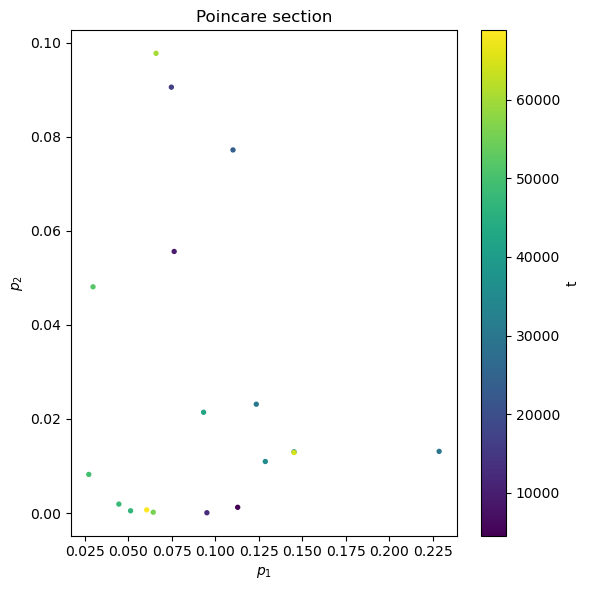

Global nonlinear rate ||F||/||A||:
0.3711564825597727

Active-mode relative rates |F_l|/|A_l|:
0 n=0, l=1, m=-1
  |A|     = 0.6324555320336759
  |F|     = 0.035110046076038556
  |F|/|A| = 0.055513857176869595
1 n=0, l=2, m=0
  |A|     = 0.5477225575051661
  |F|     = 0.08912240703410672
  |F|/|A| = 0.16271450903912446
2 n=1, l=2, m=2
  |A|     = 0.4472135954999579
  |F|     = 0.048762106492829506
  |F|/|A| = 0.10903538484405063
3 n=2, l=1, m=1
  |A|     = 0.31622776601683794
  |F|     = 0.031463461285444486
  |F|/|A| = 0.09949620073453377

Initially empty / tiny modes:
4 n=1, l=1, m=-1
  |A| = 0.0
  |F| = 0.24323282175317454
  time to reach 1e-6 amplitude ~ 4.111287254705988e-06
  time to reach 1e-3 amplitude ~ 0.004111287254705989
5 n=1, l=1, m=0
  |A| = 0.0
  |F| = 0.0
6 n=1, l=1, m=1
  |A| = 0.0
  |F| = 0.208708012388726
  time to reach 1e-6 amplitude ~ 4.791382892083055e-06
  time to reach 1e-3 amplitude ~ 0.004791382892083055
7 n=2, l=1, m=0
  |A| = 0.0
  |F| = 0.0
8 n=2, l=1, m=1

In [72]:
times_sec, pts_sec, inds_sec, level_sec = poincare_crossings_level(
    t_sec,
    A_sec,
    phase_inds=(0, 1, 2, 3),
    level=None,
    direction="either",
)

print("section level =", level_sec)
print("number of section points =", len(times_sec))

if len(times_sec) > 0:
    plt.figure(figsize=(6, 6))
    plt.scatter(pts_sec[:, 1], pts_sec[:, 2], s=8, c=times_sec, cmap="viridis")
    plt.xlabel(r"$p_1$")
    plt.ylabel(r"$p_2$")
    plt.title(r"Poincare section")
    plt.colorbar(label="t")
    plt.tight_layout()
    plt.show()
else:
    print("No crossings. Try a longer integration, different phase_inds, or different section level.")

F0 = nonlinear_rate_diagnostic(A0_balanced, C_H, mask_H)

global_rate = np.linalg.norm(F0) / np.linalg.norm(A0_balanced)
print("global slow-time scale ~", 1/global_rate)
print("global 2pi slow-time scale ~", 2*np.pi/global_rate)

In [73]:
def power_turning_section(t, A, power_index=1, direction="max"):
    p = normalized_powers_from_A(A)
    y = p[:, power_index]

    dy = np.gradient(y, t)

    pts = []
    times = []
    indices = []

    for n in range(1, len(t)):
        dy0 = dy[n - 1]
        dy1 = dy[n]

        if direction == "max":
            crossed = dy0 > 0 and dy1 <= 0
        elif direction == "min":
            crossed = dy0 < 0 and dy1 >= 0
        elif direction == "either":
            crossed = dy0 * dy1 <= 0 and abs(dy1 - dy0) > 1e-14
        else:
            raise ValueError("direction must be 'max', 'min', or 'either'.")

        if crossed:
            denom = dy1 - dy0
            if abs(denom) < 1e-14:
                continue

            frac = -dy0 / denom
            p_cross = p[n - 1] + frac * (p[n] - p[n - 1])
            t_cross = t[n - 1] + frac * (t[n] - t[n - 1])

            pts.append(p_cross)
            times.append(t_cross)
            indices.append(n)

    Nmode = A.shape[1]

    return (
        np.asarray(times),
        np.asarray(pts).reshape((-1, Nmode)),
        np.asarray(indices),
    )

number of power-section points = 47


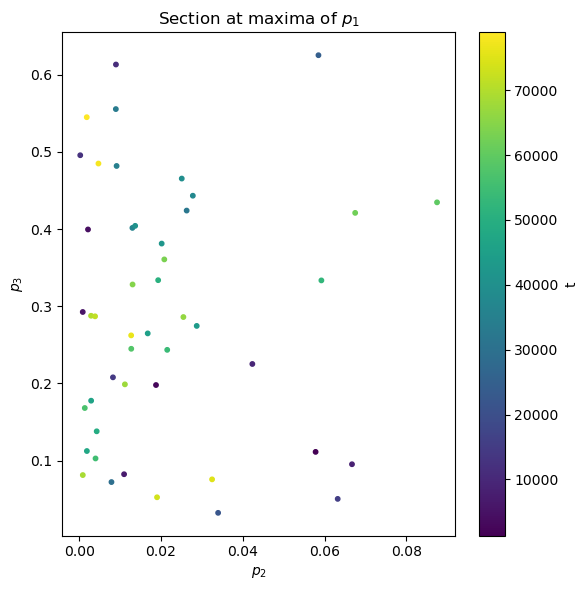

In [74]:
times_pow, pts_pow, inds_pow = power_turning_section(
    t_sec,
    A_sec,
    power_index=1,
    direction="max",
)

print("number of power-section points =", len(times_pow))

if len(times_pow) > 0:
    plt.figure(figsize=(6, 6))
    plt.scatter(pts_pow[:, 2], pts_pow[:, 3], s=10, c=times_pow, cmap="viridis")
    plt.xlabel(r"$p_2$")
    plt.ylabel(r"$p_3$")
    plt.title(r"Section at maxima of $p_1$")
    plt.colorbar(label="t")
    plt.tight_layout()
    plt.show()

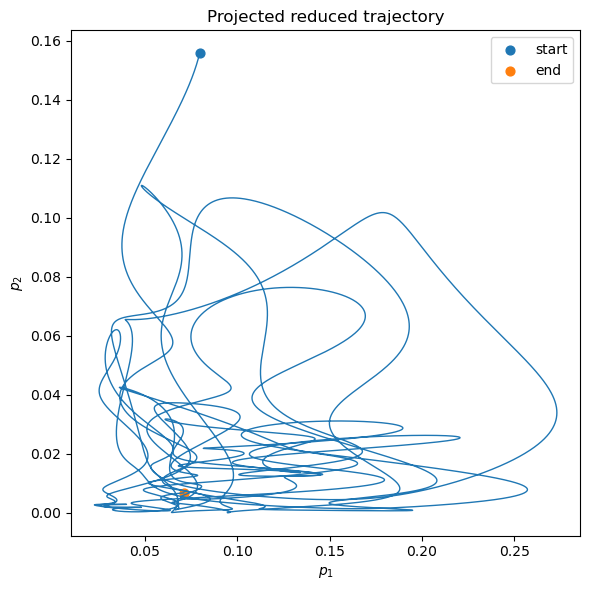

0 p range: 0.0032514418118209454 0.27077160569389 amplitude: 0.26752016388206906
1 p range: 0.022591861378554 0.27314759421483337 amplitude: 0.25055573283627935
2 p range: 5.363802319946938e-05 0.15571467596640057 amplitude: 0.1556610379432011
3 p range: 0.013143308703159457 0.7140770024838329 amplitude: 0.7009336937806734
4 p range: 2.3944046351850414e-06 0.22178549943126047 amplitude: 0.2217831050266253
5 p range: 0.0072727813020741616 0.24430839063449503 amplitude: 0.23703560933242088
6 p range: 0.002190406049882897 0.2652515311591056 amplitude: 0.2630611251092227
7 p range: 0.008518142503768814 0.22654512033536062 amplitude: 0.2180269778315918
8 p range: 0.02323459250985617 0.5869372650537804 amplitude: 0.5637026725439243


In [75]:
p = normalized_powers_from_A(A_sec)

plt.figure(figsize=(6, 6))
plt.plot(p[:, 1], p[:, 2], linewidth=1)
plt.scatter(p[0, 1], p[0, 2], s=40, label="start")
plt.scatter(p[-1, 1], p[-1, 2], s=40, label="end")
plt.xlabel(r"$p_1$")
plt.ylabel(r"$p_2$")
plt.title("Projected reduced trajectory")
plt.legend()
plt.tight_layout()
plt.show()

for j in range(p.shape[1]):
    print(j, "p range:", np.min(p[:, j]), np.max(p[:, j]), "amplitude:", np.ptp(p[:, j]))

In [77]:
def rhs_A_slow_resonant(tau, A, C, mask=None):
    """
    Slow-time resonant dynamics:

        i dA_lam/dtau = sum C[lam,i,j,k] A_i A_j bar(A_k).

    This is equivalent to the original system with tau = eps^2 t
    when phases are set to 1.
    """
    if mask is None:
        mask = 1.0

    F = np.einsum(
        "lijk,i,j,k->l",
        C * mask,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    return -1j * F


def integrate_A_slow_resonant(A0, taumax, C, mask=None, nout=20000):
    t_eval = np.linspace(0.0, taumax, nout)

    sol = solve_ivp(
        rhs_A_slow_resonant,
        (0.0, taumax),
        np.asarray(A0, dtype=complex),
        t_eval=t_eval,
        args=(C, mask),
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )

    return sol

In [78]:
A0_random, powers_random, phases_random = make_random_A0(modes, power_distribution="random", total_power=1.0, random_phases=True, seed=42)
A0 = A0_random

In [85]:
mask_H = Coeffs.build_nondiag_mask_notes(len(modes))

def integrate_A_slow_resonant(A0, taumax, C, mask=None, nout=20000):
    A0 = validate_dynamics_inputs(A0, C, mask=mask, name="slow resonant")

    t_eval = np.linspace(0.0, taumax, nout)

    sol = solve_ivp(
        rhs_A_slow_resonant,
        (0.0, taumax),
        A0,
        t_eval=t_eval,
        args=(C, mask),
        method="DOP853",
        rtol=1e-10,
        atol=1e-12,
    )

    return sol

sol_slow = integrate_A_slow_resonant(
    A0_balanced,
    taumax=50000.0,
    C=C_H,
    mask=mask_H,
    nout=100000,
)

A_slow = sol_slow.y.T
tau = sol_slow.t
p = normalized_powers_from_A(A_slow)

A_slow = sol_slow.y.T
tau = sol_slow.t

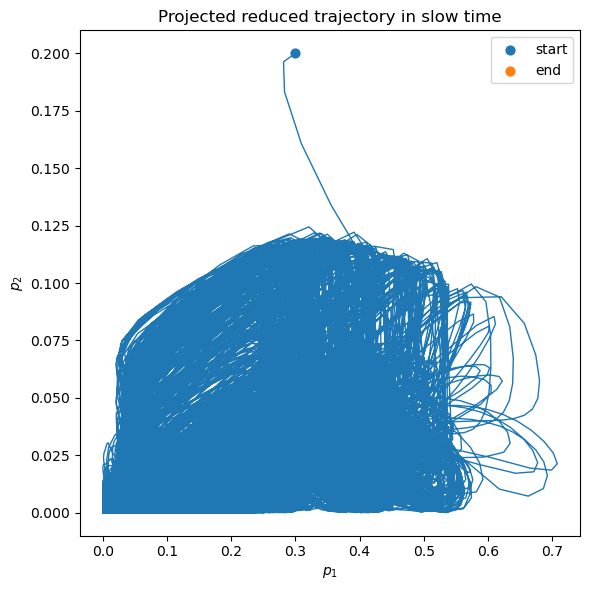

0 p range: 0.002982620464200904 0.739904110145108 amplitude: 0.7369214896809071
1 p range: 2.9266881962795595e-08 0.7080384895688393 amplitude: 0.7080384603019574
2 p range: 1.4016787596477124e-09 0.19999999999999998 amplitude: 0.1999999985983212
3 p range: 3.94455227597717e-08 0.18084542487177682 amplitude: 0.18084538542625406
4 p range: 0.0 0.4753806082288176 amplitude: 0.4753806082288176
5 p range: 0.0 0.0 amplitude: 0.0
6 p range: 0.0 0.4424568617490504 amplitude: 0.4424568617490504
7 p range: 0.0 0.0 amplitude: 0.0
8 p range: 0.0 0.1808454248717767 amplitude: 0.1808454248717767


In [91]:
p = normalized_powers_from_A(A_slow)

plt.figure(figsize=(6, 6))
plt.plot(p[:, 1], p[:, 2], linewidth=1)
plt.scatter(p[0, 1], p[0, 2], s=40, label="start")
plt.scatter(p[-1, 1], p[-1, 2], s=40, label="end")
plt.xlabel(r"$p_1$")
plt.ylabel(r"$p_2$")
plt.title("Projected reduced trajectory in slow time")
plt.legend()
plt.tight_layout()
plt.show()

for j in range(p.shape[1]):
    print(j, "p range:", np.min(p[:, j]), np.max(p[:, j]), "amplitude:", np.ptp(p[:, j]))

In [92]:
from scipy.signal import find_peaks

p = normalized_powers_from_A(A_slow)

q = 1
y = p[:, q]

peaks, _ = find_peaks(y)
troughs, _ = find_peaks(-y)

print("number of p1 maxima =", len(peaks))
print("number of p1 minima =", len(troughs))

print("p1 range:", np.min(y), np.max(y))
print("p2 range:", np.min(p[:, 2]), np.max(p[:, 2]))

if len(peaks) > 1:
    print("estimated p1 period from maxima:")
    print(np.diff(tau[peaks]))

if len(troughs) > 1:
    print("estimated p1 period from minima:")
    print(np.diff(tau[troughs]))

number of p1 maxima = 2704
number of p1 minima = 2705
p1 range: 2.9266881962795595e-08 0.7080384895688393
p2 range: 1.4016787596477124e-09 0.19999999999999998
estimated p1 period from maxima:
[ 4.00004   8.00008  16.00016  ...  5.00005  30.500305 13.00013 ]
estimated p1 period from minima:
[ 5.500055  5.00005   6.500065 ...  5.500055 36.00036  11.00011 ]


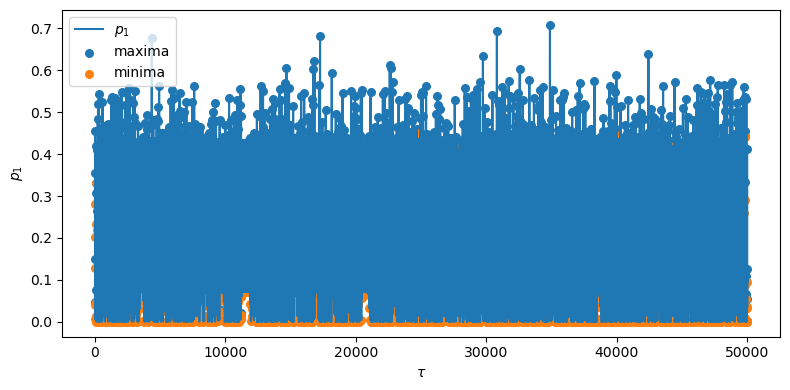

In [93]:
plt.figure(figsize=(8,4))
plt.plot(tau, p[:, 1], label=r"$p_1$")
plt.scatter(tau[peaks], p[peaks, 1], s=30, label="maxima")
plt.scatter(tau[troughs], p[troughs, 1], s=30, label="minima")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$p_1$")
plt.legend()
plt.tight_layout()
plt.show()

In [89]:
sol_slow = integrate_A_slow_resonant(
    A0_balanced,
    taumax=50000.0,
    C=C_H,
    mask=mask_H,
    nout=100000,
)

A_slow = sol_slow.y.T
tau = sol_slow.t
p = normalized_powers_from_A(A_slow)

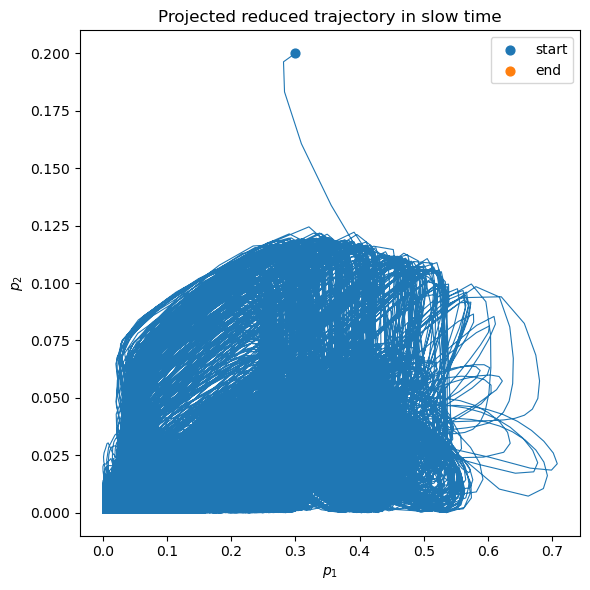

In [94]:
plt.figure(figsize=(6, 6))
plt.plot(p[:, 1], p[:, 2], linewidth=0.8)
plt.scatter(p[0, 1], p[0, 2], s=40, label="start")
plt.scatter(p[-1, 1], p[-1, 2], s=40, label="end")
plt.xlabel(r"$p_1$")
plt.ylabel(r"$p_2$")
plt.title("Projected reduced trajectory in slow time")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
rng = np.random.default_rng(123)

for trial in range(10):
    phases = rng.uniform(0, 2*np.pi, 4)

    A0_trial = make_A0_from_powers(
        [0.40, 0.30, 0.20, 0.10],
        phases=phases, len=len(modes)
    )

    sol_trial = integrate_A_slow_resonant(
        A0_trial,
        taumax=30000.0,
        C=C_H,
        mask=mask_H,
        nout=50000,
    )

    A_trial = sol_trial.y.T
    p_trial = normalized_powers_from_A(A_trial)

    plt.plot(p_trial[:, 1], p_trial[:, 2], linewidth=0.7, alpha=0.7)

plt.xlabel(r"$p_1$")
plt.ylabel(r"$p_2$")
plt.title("Projected trajectories from random initial phases")
plt.tight_layout()
plt.show()

ValueError: slow resonant C/A0 mismatch: C.shape=(9, 9, 9, 9), but len(A0)=4. Expected C.shape == (4,4,4,4).

In [96]:
def rhs_slow(A, C, mask=None):
    if mask is None:
        mask = 1.0

    F = np.einsum(
        "lijk,i,j,k->l",
        C * mask,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )

    return -1j * F


def integrate_slow_segment(A0, dtau, C, mask=None, rtol=1e-10, atol=1e-12):
    sol = solve_ivp(
        lambda t, y: rhs_slow(y, C, mask),
        (0.0, dtau),
        np.asarray(A0, dtype=complex),
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )

    return sol.y[:, -1]


def align_global_phase(A, B):
    """
    Remove the global U(1) phase between A and B.
    """
    phase = np.vdot(A, B)
    if abs(phase) == 0:
        return B
    return B * np.exp(-1j * np.angle(phase))


def largest_lyapunov_slow(
    A0,
    C,
    mask=None,
    taumax=5000.0,
    dtau=10.0,
    delta0=1e-8,
    seed=1234,
):
    rng = np.random.default_rng(seed)

    A = np.asarray(A0, dtype=complex).copy()

    dA = rng.normal(size=A.shape) + 1j*rng.normal(size=A.shape)

    # Remove component parallel to global phase direction iA.
    dA -= 1j*A * (np.vdot(1j*A, dA) / np.vdot(1j*A, 1j*A))

    dA *= delta0 / np.linalg.norm(dA)

    B = A + dA

    nsteps = int(taumax / dtau)
    logs = []
    times = []

    accum = 0.0

    for n in range(nsteps):
        A = integrate_slow_segment(A, dtau, C, mask)
        B = integrate_slow_segment(B, dtau, C, mask)

        # quotient global phase
        B = align_global_phase(A, B)

        d = B - A
        dist = np.linalg.norm(d)

        if dist == 0 or not np.isfinite(dist):
            break

        accum += np.log(dist / delta0)

        # renormalize perturbation
        d *= delta0 / dist
        B = A + d

        tau_now = (n + 1) * dtau
        times.append(tau_now)
        logs.append(accum / tau_now)

    return np.array(times), np.array(logs)

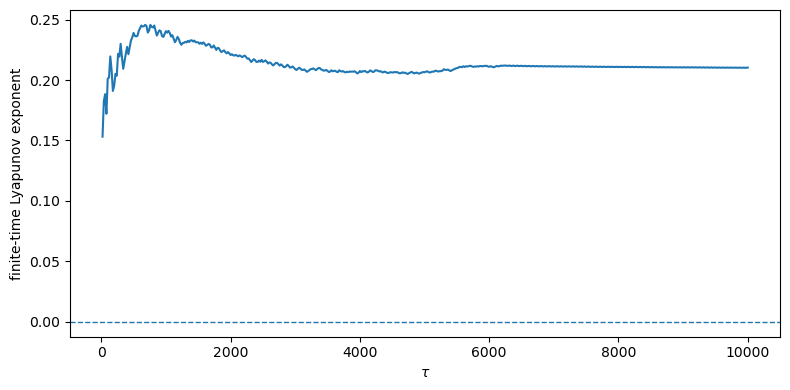

final FTLE = 0.21028441352409064


In [97]:
lyap_t, lyap_vals = largest_lyapunov_slow(
    A0_balanced,
    C_H,
    mask=mask_H,
    taumax=10000.0,
    dtau=20.0,
    delta0=1e-8,
)

plt.figure(figsize=(8,4))
plt.plot(lyap_t, lyap_vals)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel(r"finite-time Lyapunov exponent")
plt.tight_layout()
plt.show()

print("final FTLE =", lyap_vals[-1])

In [98]:
def scalar_level_section(t, A, scalar, level=None, direction="either"):
    """
    Poincare section defined by a scalar condition

        scalar(t) = level.

    Typical use:
        p = normalized_powers_from_A(A)
        scalar = p[:, q]

    Returns
    -------
    times : ndarray
        Crossing times.

    pts : ndarray
        Normalized powers at crossings. Shape = (Ncross, Nmode).

    inds : ndarray
        Indices n such that crossing occurs between n-1 and n.

    level : float
        The scalar level used.
    """

    p = normalized_powers_from_A(A)

    y = np.asarray(scalar, dtype=float)

    if level is None:
        level = np.mean(y)

    y = y - level

    pts = []
    times = []
    inds = []

    for n in range(1, len(t)):
        y0 = y[n - 1]
        y1 = y[n]

        if abs(y1 - y0) < 1e-14:
            continue

        if direction == "positive":
            crossed = (y0 < 0) and (y1 >= 0)
        elif direction == "negative":
            crossed = (y0 > 0) and (y1 <= 0)
        elif direction == "either":
            crossed = (y0 * y1 <= 0)
        else:
            raise ValueError("direction must be 'positive', 'negative', or 'either'.")

        if crossed:
            frac = -y0 / (y1 - y0)

            if frac < 0 or frac > 1:
                continue

            p_cross = p[n - 1] + frac * (p[n] - p[n - 1])
            t_cross = t[n - 1] + frac * (t[n] - t[n - 1])

            pts.append(p_cross)
            times.append(t_cross)
            inds.append(n)

    Nmode = A.shape[1]

    return (
        np.asarray(times),
        np.asarray(pts).reshape((-1, Nmode)),
        np.asarray(inds),
        level,
    )

section points = 1335


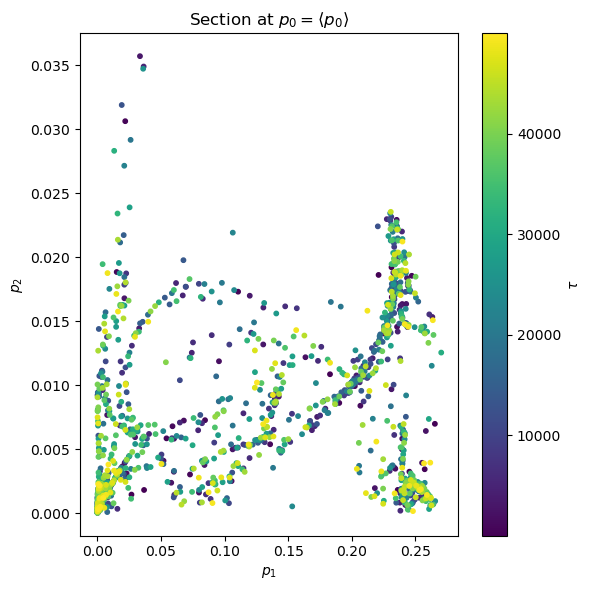

In [99]:
p = normalized_powers_from_A(A_slow)

q = 0
times_sec, pts_sec,inds_sec, level_sec =  scalar_level_section(
    tau,
    A_slow,
    scalar=p[:, q],
    level=np.mean(p[:, q]),
    direction="positive",
)

print("section points =", len(times_sec))

coords = [r for r in range(p.shape[1]) if r != q]

if len(times_sec) > 5:
    plt.figure(figsize=(6,6))
    plt.scatter(
        pts_sec[:, coords[0]],
        pts_sec[:, coords[1]],
        s=10,
        c=times_sec,
        cmap="viridis",
    )
    plt.xlabel(fr"$p_{coords[0]}$")
    plt.ylabel(fr"$p_{coords[1]}$")
    plt.title(fr"Section at $p_{q}=\langle p_{q}\rangle$")
    plt.colorbar(label=r"$\tau$")
    plt.tight_layout()
    plt.show()

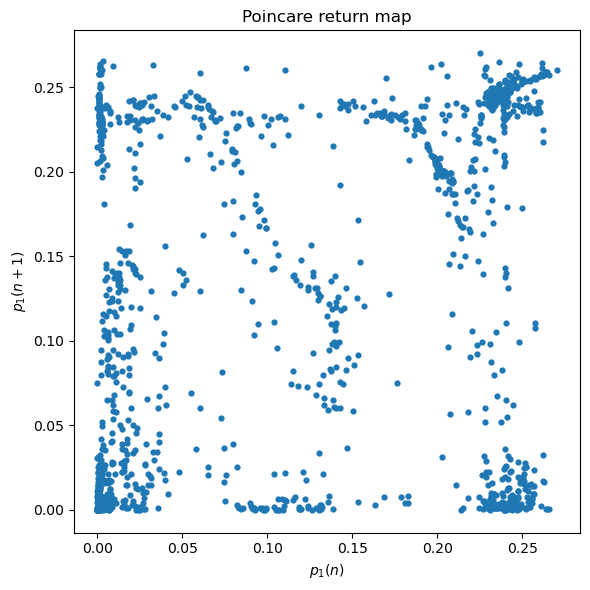

In [100]:
if len(pts_sec) > 5:
    r = coords[0]

    plt.figure(figsize=(6,6))
    plt.scatter(pts_sec[:-1, r], pts_sec[1:, r], s=12)
    plt.xlabel(fr"$p_{r}(n)$")
    plt.ylabel(fr"$p_{r}(n+1)$")
    plt.title("Poincare return map")
    plt.tight_layout()
    plt.show()

In [338]:
P = np.abs(A_slow)**2
N = np.sum(P, axis=1)

print("relative N drift =", (N[-1] - N[0]) / N[0])

relative N drift = -2.579645068667702e-07


In [103]:
def normalize_to_same_N(B, A):
    NA = np.sum(np.abs(A)**2)
    NB = np.sum(np.abs(B)**2)
    if NB == 0:
        return B
    return B * np.sqrt(NA / NB)

def project_perturbation_reduced(A, dA):
    """
    Project perturbation away from:
      1. norm-changing radial direction A,
      2. global phase direction i A.
    """
    A = np.asarray(A, dtype=complex)
    dA = np.asarray(dA, dtype=complex)

    # Remove norm-changing direction: require Re <A,dA> = 0
    AA = np.vdot(A, A).real
    if AA > 0:
        dA = dA - A * (np.vdot(A, dA).real / AA)

    # Remove global phase direction i A
    g = 1j * A
    gg = np.vdot(g, g).real
    if gg > 0:
        dA = dA - g * (np.vdot(g, dA).real / gg)

    return dA


def largest_lyapunov_slow_reduced(
    A0,
    C,
    mask=None,
    taumax=20000.0,
    dtau=20.0,
    delta0=1e-8,
    seed=1234,
):
    rng = np.random.default_rng(seed)

    A = np.asarray(A0, dtype=complex).copy()

    dA = rng.normal(size=A.shape) + 1j*rng.normal(size=A.shape)
    dA = project_perturbation_reduced(A, dA)
    dA *= delta0 / np.linalg.norm(dA)

    B = normalize_to_same_N(A + dA, A)

    nsteps = int(taumax / dtau)
    times = []
    vals = []
    accum = 0.0

    for n in range(nsteps):
        A = integrate_slow_segment(A, dtau, C, mask)
        B = integrate_slow_segment(B, dtau, C, mask)

        # Same norm and quotient global phase
        B = normalize_to_same_N(B, A)
        B = align_global_phase(A, B)

        d = B - A
        d = project_perturbation_reduced(A, d)

        dist = np.linalg.norm(d)

        if dist == 0 or not np.isfinite(dist):
            break

        accum += np.log(dist / delta0)

        d *= delta0 / dist
        B = normalize_to_same_N(A + d, A)

        tau_now = (n + 1) * dtau
        times.append(tau_now)
        vals.append(accum / tau_now)

    return np.array(times), np.array(vals)


In [ ]:

for delta0 in [1e-7, 1e-8, 1e-9]:
    lt, lv = largest_lyapunov_slow_reduced(
        A0_balanced,
        C_H,
        mask=mask_H,
        taumax=20000.0,
        dtau=20.0,
        delta0=delta0,
    )

    plt.plot(lt, lv, label=f"delta0={delta0}")

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel("reduced FTLE")
plt.legend()
plt.tight_layout()
plt.show()

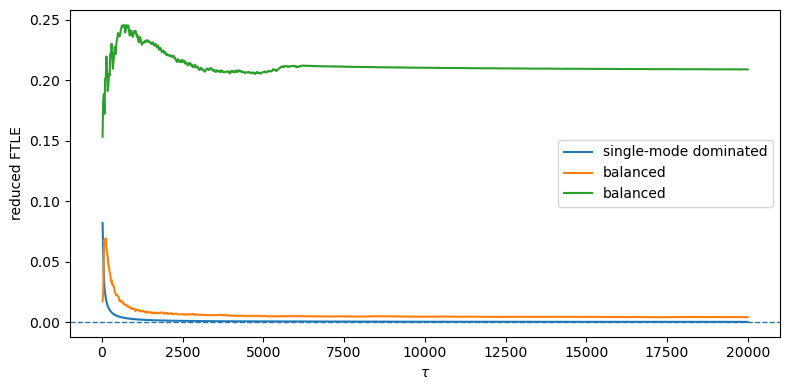

In [104]:
A0_island = make_A0_from_powers(
    [0.85, 0.10, 0.04, 0.01, 0.001, 0.92, 0.03, 0.02, 0.92],
    phases=[0.0, 0.7, 1.8, -0.4, 0.5, 1.2, -0.8, 0.3, -1.0],
)

A0_regular = make_A0_from_powers(
    [0.92, 0.02, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01],
    phases=[0.0, 0.7, 1.8, -0.4, 0.5, 1.2, -0.8, 0.3, -1.0],
)

lt_reg, lv_reg = largest_lyapunov_slow_reduced(
    A0_regular,
    C_H,
    mask=mask_H,
    taumax=20000.0,
    dtau=20.0,
    delta0=1e-8,
)

lt_island, lv_island = largest_lyapunov_slow_reduced(
    A0_island,
    C_H,
    mask=mask_H,
    taumax=20000.0,
    dtau=20.0,
    delta0=1e-8,
)

lt_bal, lv_bal = largest_lyapunov_slow_reduced(
    A0_balanced,
    C_H,
    mask=mask_H,
    taumax=20000.0,
    dtau=20.0,
    delta0=1e-8,
)

plt.figure(figsize=(8,4))
plt.plot(lt_reg, lv_reg, label="single-mode dominated")
plt.plot(lt_island, lv_island, label="balanced")
plt.plot(lt_bal, lv_bal, label="balanced")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel("reduced FTLE")
plt.legend()
plt.tight_layout()
plt.show()

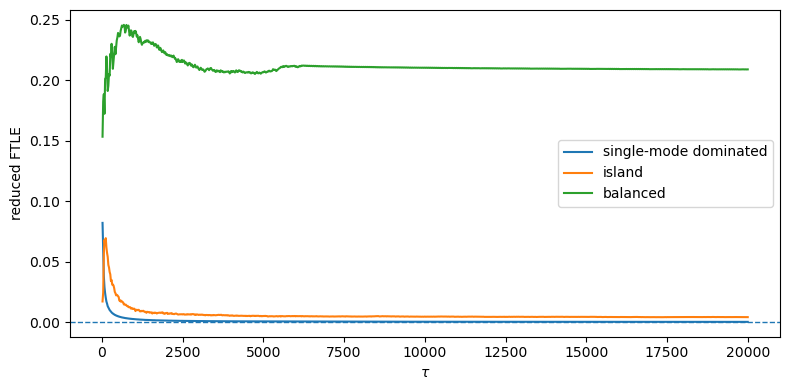

In [106]:
plt.figure(figsize=(8,4))
plt.plot(lt_reg, lv_reg, label="single-mode dominated")
plt.plot(lt_island, lv_island, label="island")
plt.plot(lt_bal, lv_bal, label="balanced")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel(r"$\tau$")
plt.ylabel("reduced FTLE")
plt.legend()
plt.tight_layout()
plt.show()

In [341]:
sol_check = integrate_A_slow_resonant(
    A0_balanced,
    taumax=20000.0,
    C=C_H,
    mask=mask_H,
    nout=20000,
)

A_check = sol_check.y.T
N_check = np.sum(np.abs(A_check)**2, axis=1)

print("relative N drift =", (N_check[-1] - N_check[0]) / N_check[0])

relative N drift = -1.035216530276273e-07


## Kinetic Equation/Power law scalings

### conservative sector

In [342]:
from kinetic_scaling import scan_power_laws, split_hermitian

C_H, C_A = split_hermitian(C)

p_values = np.linspace(-2, 5, 71) # power law exponent (n+1)^(-p)
q_values = np.linspace(-2, 5, 71) # power law exponent (ell+1)^(-q)

# Conservative Hamiltonian scaling scan
results_H = scan_power_laws(
    modes,
    C,
    np.real(omega_arr),
    p_values,
    q_values,
    eta=0.0,
    use_hamiltonian_gain_loss=True,
    kernel_width=0.05,
    shell="n",
    sort_by="residual",
)

results_H[:10]


[ScanResult(p=0.0, q=0.0, residual=0.0, residual_raw=0.0, flux_flatness=inf, flux_mean=0.0),
 ScanResult(p=0.8000000000000003, q=5.0, residual=0.0753015764963001, residual_raw=0.0753015764963001, flux_flatness=0.7174289947260925, flux_mean=0.001025116893009113),
 ScanResult(p=0.7000000000000002, q=5.0, residual=0.07536536470357305, residual_raw=0.07536536470357305, flux_flatness=0.7119048999114639, flux_mean=0.0010350783797060338),
 ScanResult(p=0.9000000000000004, q=5.0, residual=0.07548610442218484, residual_raw=0.07548610442218484, flux_flatness=0.7242198226881337, flux_mean=0.0010001848286113016),
 ScanResult(p=1.0, q=5.0, residual=0.0758236346940327, residual_raw=0.0758236346940327, flux_flatness=0.7320206795564381, flux_mean=0.0009659232587441125),
 ScanResult(p=0.6000000000000001, q=5.0, residual=0.07585322296466963, residual_raw=0.07585322296466963, flux_flatness=0.7081462443849559, flux_mean=0.0010220852684676637),
 ScanResult(p=1.1, q=5.0, residual=0.07626718081114182, residu

### Dissipative Sector

In [343]:
results_eta = scan_power_laws(
    modes,
    C,
    np.real(omega_arr),
    p_values,
    q_values,
    eta=1.0,
    use_hamiltonian_gain_loss=False,
    kernel_width=0.05,
    include_pv=True,
    shell="n",
    sort_by="residual",
)

results_eta[:10]


[ScanResult(p=2.8000000000000007, q=5.0, residual=0.29316600948597965, residual_raw=0.29316600948597965, flux_flatness=0.19474601739156497, flux_mean=0.009829521267876085),
 ScanResult(p=2.7, q=5.0, residual=0.29351508818853184, residual_raw=0.29351508818853184, flux_flatness=0.20163337639921902, flux_mean=0.010309897842150723),
 ScanResult(p=2.9000000000000004, q=5.0, residual=0.2937234582480463, residual_raw=0.2937234582480463, flux_flatness=0.1883138692885893, flux_mean=0.009402030594039495),
 ScanResult(p=2.6000000000000005, q=5.0, residual=0.2948081771364202, residual_raw=0.2948081771364202, flux_flatness=0.20898807998323995, flux_mean=0.010851213699153392),
 ScanResult(p=3.0, q=5.0, residual=0.29516248214876206, residual_raw=0.29516248214876206, flux_flatness=0.18232221037307889, flux_mean=0.009020587524076792),
 ScanResult(p=2.5, q=5.0, residual=0.2970970342837238, residual_raw=0.2970970342837238, flux_flatness=0.21681929509414852, flux_mean=0.011462986518142468),
 ScanResult(p=

In [344]:
# 1. Is the minimum stuck on the grid boundary?
p_values = np.linspace(-5, 2, 71)
q_values = np.linspace(0, 10, 101)


In [345]:
# 2. Compare Hamiltonian-only vs raw tensor
results_H = scan_power_laws(
    modes, C, np.real(omega_arr),
    p_values, q_values,
    eta=0.0,
    use_hamiltonian_gain_loss=True,
    kernel_width=0.05,
    shell="n",
)

results_raw_no_pv = scan_power_laws(
    modes, C, np.real(omega_arr),
    p_values, q_values,
    eta=1.0,
    use_hamiltonian_gain_loss=False,
    kernel_width=0.05,
    include_pv=False,
    shell="n",
)


In [346]:
# 3. Sort by flux flatness instead of stationarity
flux_eta = scan_power_laws(
    modes, C, np.real(omega_arr),
    p_values, q_values,
    eta=1.0,
    use_hamiltonian_gain_loss=False,
    kernel_width=0.05,
    include_pv=True,
    shell="n",
    sort_by="flux_flatness",
)


In [347]:
for width in [0.02, 0.05, 0.1, 0.2]:
    r = scan_power_laws(
        modes, C, np.real(omega_arr),
        p_values, q_values,
        eta=1.0,
        use_hamiltonian_gain_loss=False,
        kernel_width=width,
        include_pv=True,
        shell="n",
    )
    print(width, r[0])


0.02 ScanResult(p=2.0, q=10.0, residual=0.0007869461387486132, residual_raw=0.0007869461387486132, flux_flatness=0.2668009120810233, flux_mean=1.166990028863792e-06)
0.05 ScanResult(p=2.0, q=10.0, residual=0.00031477845549944517, residual_raw=0.00031477845549944517, flux_flatness=0.2668009120810233, flux_mean=4.667960115455167e-07)
0.1 ScanResult(p=2.0, q=10.0, residual=0.00015738922774972258, residual_raw=0.00015738922774972258, flux_flatness=0.2668009120810233, flux_mean=2.3339800577275835e-07)
0.2 ScanResult(p=2.0, q=10.0, residual=7.869461387486129e-05, residual_raw=7.869461387486129e-05, flux_flatness=0.2668009120810233, flux_mean=1.1669900288637918e-07)


In [348]:
for width in [0.02, 0.05, 0.1, 0.2]:
    r = scan_power_laws(
        modes, C, np.real(omega_arr),
        p_values, q_values,
        eta=1.0,
        use_hamiltonian_gain_loss=False,
        kernel_width=width,
        include_pv=True,
        shell="n",
        residual_kind="shape",
    )
    print(width, r[0])


0.02 ScanResult(p=0.20000000000000018, q=0.2, residual=0.26745258760717183, residual_raw=2994.2742747742677, flux_flatness=0.4467648051883086, flux_mean=13117.945492158377)
0.05 ScanResult(p=0.20000000000000018, q=0.2, residual=0.2674525876071718, residual_raw=1197.709709909707, flux_flatness=0.44676480518830847, flux_mean=5247.17819686335)
0.1 ScanResult(p=0.20000000000000018, q=0.2, residual=0.2674525876071718, residual_raw=598.8548549548535, flux_flatness=0.44676480518830847, flux_mean=2623.589098431675)
0.2 ScanResult(p=0.20000000000000018, q=0.2, residual=0.2674525876071718, residual_raw=299.42742747742676, flux_flatness=0.44676480518830847, flux_mean=1311.7945492158376)


In [349]:
r = scan_power_laws(
    modes, C, np.real(omega_arr),
    p_values, q_values,
    eta=1.0,
    use_hamiltonian_gain_loss=False,
    kernel_width=0.05,
    include_pv=True,
    shell="n",
    residual_kind="shape",
)

r[:10]


[ScanResult(p=0.20000000000000018, q=0.2, residual=0.2674525876071718, residual_raw=1197.709709909707, flux_flatness=0.44676480518830847, flux_mean=5247.17819686335),
 ScanResult(p=0.20000000000000018, q=0.1, residual=0.2674591408723823, residual_raw=1386.2862436417631, flux_flatness=0.4455292844495498, flux_mean=6562.595363744604),
 ScanResult(p=0.20000000000000018, q=0.30000000000000004, residual=0.2674813304506055, residual_raw=1035.32781720793, flux_flatness=0.44804575932279983, flux_mean=4198.079805048747),
 ScanResult(p=0.20000000000000018, q=0.0, residual=0.2675079504646541, residual_raw=1605.452793164228, flux_flatness=0.4443453894847651, flux_mean=8213.151602847602),
 ScanResult(p=0.20000000000000018, q=0.4, residual=0.26753926807504663, residual_raw=895.3999046972435, flux_flatness=0.4493661878734581, flux_mean=3360.784673233778),
 ScanResult(p=0.20000000000000018, q=0.5, residual=0.2676210824918523, residual_raw=774.7383452671912, flux_flatness=0.45072038252551155, flux_mean

In [350]:
p_values = np.linspace(3, 12, 91)
q_values = np.linspace(-1, 2, 61)


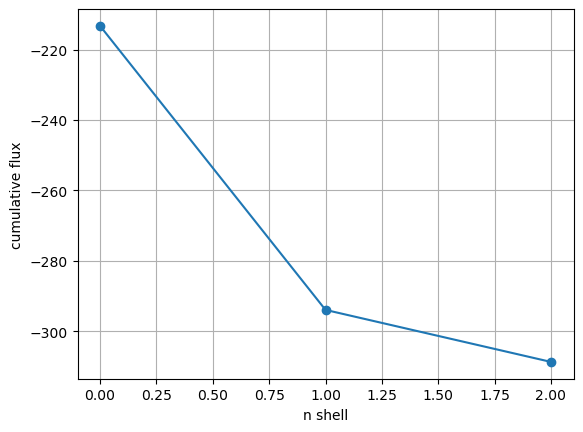

In [351]:
from kinetic_scaling import (
    split_hermitian, power_law_spectrum, kinetic_rhs_general,
    build_nondiag_mask, shell_flux
)

C_H, C_A = split_hermitian(C)
C_eff = C_H + C_A

occ = power_law_spectrum(modes, p=5.0, q=0.1)
mask = build_nondiag_mask(len(modes))

rhs = kinetic_rhs_general(
    occ,
    C_eff,
    np.real(omega_arr),
    mask=mask,
    kernel_width=0.05,
    include_pv=True,
)

shells, flux = shell_flux(rhs, modes, shell="n")

plt.plot(shells, flux, marker="o")
plt.xlabel("n shell")
plt.ylabel("cumulative flux")
plt.grid(True)


## Equilibrium solutions

In [107]:
def pure_mode_equilibria(C, mask=None, N0=1.0, tol=1e-12):
    Ceff = np.array(C, copy=True)

    if mask is not None:
        Ceff = np.where(mask, Ceff, 0.0)

    M = Ceff.shape[0]
    out = []

    for q in range(M):
        forcing = Ceff[:, q, q, q] * N0**1.5

        offdiag = forcing.copy()
        offdiag[q] = 0.0

        err = np.linalg.norm(offdiag)

        mu = N0 * Ceff[q, q, q, q]

        out.append({
            "mode": q,
            "is_equilibrium": err < tol,
            "offdiag_forcing": err,
            "mu": mu,
        })

    return out

In [ ]:
pure_eq = pure_mode_equilibria(C_H, mask_H)

for x in pure_eq:
    print(x)



{'mode': 0, 'is_equilibrium': False, 'offdiag_forcing': 0.5171161212189999, 'mu': 0j}
{'mode': 1, 'is_equilibrium': True, 'offdiag_forcing': 0.0, 'mu': 0j}
{'mode': 2, 'is_equilibrium': True, 'offdiag_forcing': 0.0, 'mu': 0j}
{'mode': 3, 'is_equilibrium': False, 'offdiag_forcing': 0.5264454464070376, 'mu': 0j}
{'mode': 4, 'is_equilibrium': False, 'offdiag_forcing': 0.5036396921504671, 'mu': 0j}
{'mode': 5, 'is_equilibrium': False, 'offdiag_forcing': 0.2575367138927732, 'mu': 0j}
{'mode': 6, 'is_equilibrium': False, 'offdiag_forcing': 0.24280794239743952, 'mu': 0j}
{'mode': 7, 'is_equilibrium': False, 'offdiag_forcing': 0.5508567678247954, 'mu': 0j}
{'mode': 8, 'is_equilibrium': False, 'offdiag_forcing': 0.5264454464070377, 'mu': 0j}


In [109]:
from scipy.optimize import root


def nonlinear_force(A, C, mask=None):
    Ceff = C if mask is None else np.where(mask, C, 0.0)

    return np.einsum(
        'lijk,i,j,k->l',
        Ceff,
        A,
        A,
        np.conjugate(A),
        optimize=True,
    )


def unpack_equilibrium_variables(x, M, ref):
    """
    Gauge: Im(a[ref]) = 0.

    Variables:
      Re(a_0 ... a_{M-1})
      Im(a_j), j != ref
      mu
    """
    re = x[:M]

    im = np.zeros(M)
    im_indices = [j for j in range(M) if j != ref]

    im[:] = 0.0
    im[im_indices] = x[M:M + M - 1]

    mu = x[-1]

    return re + 1j * im, mu


def pack_equilibrium_variables(a, mu, ref):
    M = len(a)
    im_indices = [j for j in range(M) if j != ref]

    return np.concatenate([
        np.real(a),
        np.imag(a)[im_indices],
        [mu],
    ])


def equilibrium_residual(x, C, mask, N0, ref):
    M = C.shape[0]

    a, mu = unpack_equilibrium_variables(x, M, ref)

    G = nonlinear_force(a, C, mask) - mu * a

    # One equation is redundant because of U(1).
    # Drop Im G_ref.
    imag_indices = [j for j in range(M) if j != ref]

    return np.concatenate([
        np.real(G),
        np.imag(G)[imag_indices],
        [np.vdot(a, a).real - N0],
    ])


def find_equilibrium(
    Aguess,
    C,
    mask=None,
    N0=1.0,
    ref=None,
    tol=1e-11,
):
    Aguess = np.asarray(Aguess, dtype=complex)

    Aguess *= np.sqrt(N0 / np.vdot(Aguess, Aguess).real)

    if ref is None:
        ref = np.argmax(np.abs(Aguess))

    # Rotate the initial guess into our phase gauge.
    phase = np.angle(Aguess[ref])
    Aguess *= np.exp(-1j * phase)

    # crude initial nonlinear frequency
    F = nonlinear_force(Aguess, C, mask)
    mu0 = np.vdot(Aguess, F).real / N0

    x0 = pack_equilibrium_variables(Aguess, mu0, ref)

    sol = root(
        equilibrium_residual,
        x0,
        args=(C, mask, N0, ref),
        tol=tol,
    )

    a, mu = unpack_equilibrium_variables(sol.x, len(Aguess), ref)

    # canonical global phase
    j = np.argmax(np.abs(a))
    a *= np.exp(-1j * np.angle(a[j]))

    res = np.linalg.norm(
        nonlinear_force(a, C, mask) - mu * a
    )

    return {
        "success": sol.success,
        "A": a,
        "mu": mu,
        "residual": res,
        "message": sol.message,
    }

In [110]:
eq_bal = find_equilibrium(
    A0_balanced,
    C_H,
    mask_H,
)

print(eq_bal["success"])
print(eq_bal["mu"])
print(eq_bal["residual"])
print(np.abs(eq_bal["A"])**2)
print(np.angle(eq_bal["A"]))

False
-0.16961980646084207
0.3671856888896363
[4.57804072e-04 3.88330185e-01 1.46186222e-01 5.21786921e-03
 2.00900543e-01 7.85825430e-09 2.53242032e-01 2.10172392e-10
 5.85432894e-03]
[ 9.17441827e-01 -3.18082588e-17 -6.51171306e-01  3.07997479e+00
  2.40940669e+00  3.32766352e-01  1.63712351e+00 -4.94988818e-01
 -3.06725337e+00]


In [112]:
def stability_matrix(a, mu, C, mask=None):
    Ceff = C if mask is None else np.where(mask, C, 0.0)

    a = np.asarray(a, dtype=complex)
    M = len(a)

    P1 = np.einsum(
        'lrjk,j,k->lr',
        Ceff,
        a,
        np.conjugate(a),
        optimize=True,
    )

    P2 = np.einsum(
        'lirk,i,k->lr',
        Ceff,
        a,
        np.conjugate(a),
        optimize=True,
    )

    P = P1 + P2 - mu * np.eye(M)

    Q = np.einsum(
        'lijr,i,j->lr',
        Ceff,
        a,
        a,
        optimize=True,
    )

    L = np.block([
        [-1j * P,             -1j * Q],
        [ 1j * np.conjugate(Q), 1j * np.conjugate(P)],
    ])

    return L


def equilibrium_stability(a, mu, C, mask=None):
    L = stability_matrix(a, mu, C, mask)

    eigvals, eigvecs = np.linalg.eig(L)

    order = np.argsort(np.real(eigvals))[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    return {
        "matrix": L,
        "eigenvalues": eigvals,
        "eigenvectors": eigvecs,
        "max_growth_rate": np.max(np.real(eigvals)),
    }

In [ ]:
stab = equilibrium_stability(
    eq_bal["A"],
    eq_bal["mu"],
    C_H,
    mask_H,
)

print("largest Re(lambda) =",
      stab["max_growth_rate"])

print(stab["eigenvalues"])

In [113]:
def pure_state(q, M, N0=1.0):
    a = np.zeros(M, dtype=complex)
    a[q] = np.sqrt(N0)
    return a


for q in [1, 2]:
    aeq = pure_state(q, C_H.shape[0])

    stab = equilibrium_stability(
        aeq,
        0.0,
        C_H,
        mask_H,
    )

    eig = stab["eigenvalues"]

    print(f"\nmode {q}")
    print("max Re(lambda) =", np.max(np.real(eig)))

    for z in eig:
        print(f"{z.real:+.6e} {z.imag:+.6e}i")


mode 1
max Re(lambda) = 1.691395813690692
+1.691396e+00 -3.813882e-16i
+7.752436e-01 -3.493107e-01i
+7.752436e-01 +3.493107e-01i
+0.000000e+00 +0.000000e+00i
+0.000000e+00 +0.000000e+00i
+0.000000e+00 -0.000000e+00i
+0.000000e+00 -0.000000e+00i
-6.107064e-02 +5.299729e-17i
-1.143729e-01 +2.823647e-01i
-1.143729e-01 -2.823647e-01i
-1.215179e-01 +5.995687e-01i
-1.215179e-01 -5.995687e-01i
-2.012869e-01 +4.261951e-01i
-2.012869e-01 -4.261951e-01i
-3.380659e-01 -2.403196e-01i
-3.380659e-01 +2.403196e-01i
-5.399365e-01 -2.148800e-16i
-1.090389e+00 -7.833602e-17i

mode 2
max Re(lambda) = 0.2961202501578809
+2.961203e-01 +7.676344e-01i
+2.961203e-01 -7.676344e-01i
+2.445312e-01 -5.053366e-01i
+2.445312e-01 +5.053366e-01i
+4.535775e-02 +2.192397e-01i
+4.535775e-02 -2.192397e-01i
+0.000000e+00 +0.000000e+00i
+0.000000e+00 -0.000000e+00i
+0.000000e+00 -0.000000e+00i
+0.000000e+00 +0.000000e+00i
-2.395045e-02 +1.368172e+00i
-2.395045e-02 -1.368172e+00i
-4.535775e-02 +2.192397e-01i
-4.535775e-02 

In [114]:
def rotating_rhs(A, mu, C, mask=None):
    return -1j * (nonlinear_force(A, C, mask) - mu * A)

In [115]:
import numpy as np
from scipy.linalg import null_space


def real_vector(A):
    A = np.asarray(A, dtype=complex)
    return np.concatenate([A.real, A.imag])


def complex_vector(x):
    M = len(x) // 2
    return x[:M] + 1j*x[M:]


def rotating_rhs_real(x, mu, C, mask=None):
    A = complex_vector(x)

    dA = -1j * (
        nonlinear_force(A, C, mask)
        - mu * A
    )

    return real_vector(dA)


def numerical_jacobian_equilibrium(
    a,
    mu,
    C,
    mask=None,
    h=1e-7,
):
    x0 = real_vector(a)
    n = len(x0)

    J = np.zeros((n, n))

    for j in range(n):
        dx = np.zeros(n)
        dx[j] = h

        fp = rotating_rhs_real(
            x0 + dx, mu, C, mask
        )

        fm = rotating_rhs_real(
            x0 - dx, mu, C, mask
        )

        J[:, j] = (fp - fm) / (2*h)

    return J

In [116]:
def reduced_tangent_basis(a):
    a = np.asarray(a, dtype=complex)

    radial = real_vector(a)
    phase  = real_vector(1j * a)

    radial /= np.linalg.norm(radial)
    phase  /= np.linalg.norm(phase)

    # Columns span the space orthogonal to both
    constraints = np.column_stack([
        radial,
        phase,
    ])

    Q = null_space(constraints.T)

    return Q

In [117]:
def reduced_equilibrium_stability(
    a,
    mu,
    C,
    mask=None,
    h=1e-7,
):
    J = numerical_jacobian_equilibrium(
        a, mu, C, mask, h=h
    )

    Q = reduced_tangent_basis(a)

    Jred = Q.T @ J @ Q

    eig = np.linalg.eigvals(Jred)
    eig = eig[np.argsort(eig.real)[::-1]]

    return {
        "J_full": J,
        "J_reduced": Jred,
        "eigenvalues": eig,
        "max_growth_rate": np.max(eig.real),
    }

In [118]:
for q in [1, 2]:

    a = pure_state(
        q,
        C_H.shape[0],
        N0=1.0,
    )

    stab = reduced_equilibrium_stability(
        a,
        0.0,
        C_H,
        mask_H,
    )

    print(f"\nmode {q}")
    print(
        "max reduced Re(lambda) =",
        stab["max_growth_rate"]
    )

    for z in stab["eigenvalues"]:
        print(
            f"{z.real:+.8e} "
            f"{z.imag:+.8e}i"
        )


mode 1
max reduced Re(lambda) = 1.6913958136906992
+1.69139581e+00 +0.00000000e+00i
+7.75243598e-01 -3.49310704e-01i
+7.75243598e-01 +3.49310704e-01i
+0.00000000e+00 +0.00000000e+00i
+0.00000000e+00 +0.00000000e+00i
-6.10706438e-02 +0.00000000e+00i
-1.14372916e-01 -2.82364741e-01i
-1.14372916e-01 +2.82364741e-01i
-1.21517863e-01 -5.99568699e-01i
-1.21517863e-01 +5.99568699e-01i
-2.01286903e-01 -4.26195102e-01i
-2.01286903e-01 +4.26195102e-01i
-3.38065916e-01 -2.40319560e-01i
-3.38065916e-01 +2.40319560e-01i
-5.39936501e-01 +0.00000000e+00i
-1.09038867e+00 +0.00000000e+00i

mode 2
max reduced Re(lambda) = 0.2961202501578811
+2.96120250e-01 -7.67634391e-01i
+2.96120250e-01 +7.67634391e-01i
+2.44531215e-01 -5.05336579e-01i
+2.44531215e-01 +5.05336579e-01i
+4.53577480e-02 -2.19239728e-01i
+4.53577480e-02 +2.19239728e-01i
+0.00000000e+00 +0.00000000e+00i
+0.00000000e+00 +0.00000000e+00i
-2.39504521e-02 -1.36817193e+00i
-2.39504521e-02 +1.36817193e+00i
-4.53577480e-02 -2.19239728e-01i
-4.53

In [119]:
T = np.where(mask_H, C_H, 0.0)

err_ij = np.max(np.abs(
    T - T.transpose(0, 2, 1, 3)
))

err_out = np.max(np.abs(
    T - T.transpose(3, 1, 2, 0)
))

err_H = np.max(np.abs(
    T - np.conjugate(T.transpose(1, 0, 3, 2))
))

print("i <-> j symmetry:       ", err_ij)
print("lambda <-> k symmetry:  ", err_out)
print("Hermitian pair symmetry:", err_H)

i <-> j symmetry:        0.9587300341712092
lambda <-> k symmetry:   0.9587300341712092
Hermitian pair symmetry: 0.0


In [120]:
T = np.where(mask_H, C_H, 0.0)

# This does NOT change F_lambda because A_i A_j is symmetric.
T_eff = 0.5 * (
    T + T.transpose(0, 2, 1, 3)
)

print(
    "i <-> j:",
    np.max(np.abs(
        T_eff - T_eff.transpose(0, 2, 1, 3)
    ))
)

print(
    "lambda <-> k:",
    np.max(np.abs(
        T_eff - T_eff.transpose(3, 1, 2, 0)
    ))
)

print(
    "Hermitian pair:",
    np.max(np.abs(
        T_eff
        - np.conjugate(
            T_eff.transpose(1, 0, 3, 2)
        )
    ))
)

i <-> j: 0.0
lambda <-> k: 0.9587300341712092
Hermitian pair: 0.5867490752097481


In [121]:
def symmetry_errors(T):
    T = np.asarray(T)

    return {
        "i_j": np.max(np.abs(
            T - T.transpose(0, 2, 1, 3)
        )),
        "lambda_k": np.max(np.abs(
            T - T.transpose(3, 1, 2, 0)
        )),
        "Hermitian": np.max(np.abs(
            T - np.conjugate(
                T.transpose(1, 0, 3, 2)
            )
        )),
    }


print("C_H:")
print(symmetry_errors(C_H))

print("\nmasked C_H:")
print(symmetry_errors(
    np.where(mask_H, C_H, 0.0)
))

C_H:
{'i_j': 1.2590864457072182, 'lambda_k': 1.2590864457072182, 'Hermitian': 0.0}

masked C_H:
{'i_j': 0.9587300341712092, 'lambda_k': 0.9587300341712092, 'Hermitian': 0.0}


In [122]:
M = np.asarray(mask_H, dtype=bool)

print(
    "mask i <-> j mismatches:",
    np.count_nonzero(
        M ^ M.transpose(0, 2, 1, 3)
    )
)

print(
    "mask lambda <-> k mismatches:",
    np.count_nonzero(
        M ^ M.transpose(3, 1, 2, 0)
    )
)

print(
    "mask pair mismatches:",
    np.count_nonzero(
        M ^ M.transpose(1, 0, 3, 2)
    )
)

mask i <-> j mismatches: 0
mask lambda <-> k mismatches: 0
mask pair mismatches: 0


In [123]:
for q in range(C_H.shape[0]):
    print(
        q,
        "mask qqqq =", mask_H[q,q,q,q],
        "C_H qqqq =", C_H[q,q,q,q],
        "masked =", T[q,q,q,q],
    )

0 mask qqqq = False C_H qqqq = (-2.065842558322842+0j) masked = 0j
1 mask qqqq = False C_H qqqq = (-1.2627596437079298+0j) masked = 0j
2 mask qqqq = False C_H qqqq = (0.40823900862723744+0j) masked = 0j
3 mask qqqq = False C_H qqqq = (-0.37720176707357156+0j) masked = 0j
4 mask qqqq = False C_H qqqq = (0.7590238602793605+0j) masked = 0j
5 mask qqqq = False C_H qqqq = (1.138535790419041+0j) masked = 0j
6 mask qqqq = False C_H qqqq = (0.7590238602793605+0j) masked = 0j
7 mask qqqq = False C_H qqqq = (-0.5658026506103575+0j) masked = 0j
8 mask qqqq = False C_H qqqq = (-0.37720176707357156+0j) masked = 0j


## define canonical hamiltonian coefficient

In [124]:
def swap_ij(T):
    return T.transpose(0, 2, 1, 3)


def swap_lk(T):
    return T.transpose(3, 1, 2, 0)


def hermitian_pair(T):
    return np.conjugate(
        T.transpose(1, 0, 3, 2)
    )


def project_quartic_hamiltonian(T):
    S0 = T
    S1 = swap_ij(T)
    S2 = swap_lk(T)
    S3 = swap_lk(swap_ij(T))

    return (
        S0 + S1 + S2 + S3
        + hermitian_pair(S0)
        + hermitian_pair(S1)
        + hermitian_pair(S2)
        + hermitian_pair(S3)
    ) / 8.0

In [125]:
T0 = np.where(mask_H, C, 0.0)

C_Ham = project_quartic_hamiltonian(T0)

print(symmetry_errors(C_Ham))

{'i_j': 1.1188630228279524e-16, 'lambda_k': 1.2412670766236366e-16, 'Hermitian': 2.2887833992611187e-16}


In [128]:
eq_bal_Ham = find_equilibrium(
    A0_balanced,
    C_Ham,
    mask=None,
)

print("success  =", eq_bal_Ham["success"])
print("mu       =", eq_bal_Ham["mu"])
print("residual =", eq_bal_Ham["residual"])

print("\nmodal powers:")
print(np.abs(eq_bal_Ham["A"])**2)

print("\nphases:")
print(np.angle(eq_bal_Ham["A"]))

success  = True
mu       = -0.016947493359377817
residual = 9.02053248174916e-15

modal powers:
[2.26257014e-02 8.27801895e-01 4.89660856e-02 1.40225450e-03
 1.92590867e-02 2.10784812e-35 7.85427223e-02 3.78160314e-36
 1.40225450e-03]

phases:
[-1.34817914e+00  9.25282794e-17  1.64662677e+00 -1.07135775e+00
  2.80771766e+00 -6.61835351e-01  2.69229819e+00 -3.56057050e-01
 -1.07135775e+00]


In [129]:
stab_bal_Ham = reduced_equilibrium_stability(
    eq_bal_Ham["A"],
    eq_bal_Ham["mu"],
    C_Ham,
    mask=None,   # if C_Ham already masked
)

print(
    "max reduced Re(lambda) =",
    stab_bal_Ham["max_growth_rate"]
)

for z in stab_bal_Ham["eigenvalues"]:
    print(f"{z.real:+.8e} {z.imag:+.8e}i")

max reduced Re(lambda) = 0.8189799326942324
+8.18979933e-01 +0.00000000e+00i
+3.41130547e-01 +0.00000000e+00i
+8.89836133e-02 -4.54210633e-01i
+8.89836133e-02 +4.54210633e-01i
+1.54895021e-06 +0.00000000e+00i
+1.03172246e-10 -7.34584339e-01i
+1.03172246e-10 +7.34584339e-01i
+3.04942966e-12 -1.90299676e-01i
+3.04942966e-12 +1.90299676e-01i
-2.67081771e-11 -3.30836986e-01i
-2.67081771e-11 +3.30836986e-01i
-1.54894636e-06 +0.00000000e+00i
-8.89836134e-02 -4.54210633e-01i
-8.89836134e-02 +4.54210633e-01i
-3.41130547e-01 +0.00000000e+00i
-8.18979933e-01 +0.00000000e+00i


In [137]:
def reduced_equilibrium_stability(
    a,
    mu,
    C,
    mask=None,
    h=1e-7,
):
    J = numerical_jacobian_equilibrium(
        a, mu, C, mask, h=h
    )

    Q = reduced_tangent_basis(a)

    Jred = Q.T @ J @ Q

    eigvals, eigvecs = np.linalg.eig(Jred)

    order = np.argsort(eigvals.real)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    return {
        "J_full": J,
        "J_reduced": Jred,
        "Q": Q,
        "eigenvalues": eigvals,
        "eigenvectors": eigvecs,
        "max_growth_rate": eigvals[0].real,
    }

In [140]:
def most_unstable_perturbation(stab, a):
    """
    Return the most unstable eigenvalue and its eigenvector
    mapped back to complex A-space.
    """
    eigvals = stab["eigenvalues"]
    eigvecs = stab["eigenvectors"]
    Q = stab["Q"]

    idx = np.argmax(eigvals.real)

    lam = eigvals[idx]
    v_red = eigvecs[:, idx]

    # Map reduced coordinates -> full 2M-dimensional real coordinates
    v_full = Q @ v_red

    # For a real unstable eigenvalue the eigenvector should be real
    # up to numerical roundoff.
    if abs(lam.imag) < 1e-10:
        v_full = np.real(v_full)

    M = len(a)

    dA = (
        v_full[:M]
        + 1j * v_full[M:]
    )

    # Make absolutely sure it is in the same reduced tangent space
    dA = project_perturbation_reduced(a, dA)

    dA /= np.linalg.norm(dA)

    return lam, dA

In [143]:
stab_bal_Ham = reduced_equilibrium_stability(
    eq_bal_Ham["A"],
    eq_bal_Ham["mu"],
    C_Ham,
    mask=None,
)

print(stab_bal_Ham.keys())

dict_keys(['J_full', 'J_reduced', 'Q', 'eigenvalues', 'eigenvectors', 'max_growth_rate'])


In [144]:
a_eq = eq_bal_Ham["A"]

lam_u, v_u = most_unstable_perturbation(
    stab_bal_Ham,
    a_eq,
)

print("unstable eigenvalue =", lam_u)
print("||v_u|| =", np.linalg.norm(v_u))

unstable eigenvalue = (0.8189799326942324+0j)
||v_u|| = 1.0


In [145]:
def evolve_unstable_branch(
    a_eq,
    A0,
    C,
    mask=None,
    taumax=30.0,
    dtau=0.02,
):
    Aref = np.asarray(a_eq, dtype=complex).copy()
    A    = np.asarray(A0,   dtype=complex).copy()

    times = [0.0]
    distances = []
    states = [A.copy()]
    refs   = [Aref.copy()]

    def reduced_distance(Aref, A):
        B = normalize_to_same_N(A, Aref)
        B = align_global_phase(Aref, B)

        d = B - Aref
        d = project_perturbation_reduced(Aref, d)

        return np.linalg.norm(d)

    distances.append(reduced_distance(Aref, A))

    nsteps = int(np.ceil(taumax / dtau))

    for n in range(nsteps):

        Aref = integrate_slow_segment(
            Aref,
            dtau,
            C,
            mask,
        )

        A = integrate_slow_segment(
            A,
            dtau,
            C,
            mask,
        )

        tau = (n + 1) * dtau

        times.append(tau)
        distances.append(
            reduced_distance(Aref, A)
        )

        states.append(A.copy())
        refs.append(Aref.copy())

    return (
        np.asarray(times),
        np.asarray(distances),
        np.asarray(states),
        np.asarray(refs),
    )

In [147]:
a_eq  = eq_bal_Ham["A"]
mu_eq = eq_bal_Ham["mu"]

eps = 1e-8

def perturb_equilibrium(a_eq, v_u, eps, sign=1.0):
    A0 = a_eq + sign * eps * v_u

    # Put it back on the same conserved-N surface.
    # This only changes the perturbation at O(eps^2).
    A0 = normalize_to_same_N(A0, a_eq)

    # Remove any tiny global-phase displacement
    A0 = align_global_phase(a_eq, A0)

    return A0


Aplus0  = perturb_equilibrium(a_eq, v_u, eps, +1.0)
Aminus0 = perturb_equilibrium(a_eq, v_u, eps, -1.0)

In [161]:
t_plus, d_plus, A_plus, Aref_plus = evolve_unstable_branch(
    a_eq,
    Aplus0,
    C_Ham,
    mask=None,
    taumax=30.0,
    dtau=0.02,
)

t_minus, d_minus, A_minus, Aref_minus = evolve_unstable_branch(
    a_eq,
    Aminus0,
    C_Ham,
    mask=None,
    taumax=30.0,
    dtau=0.02,
)

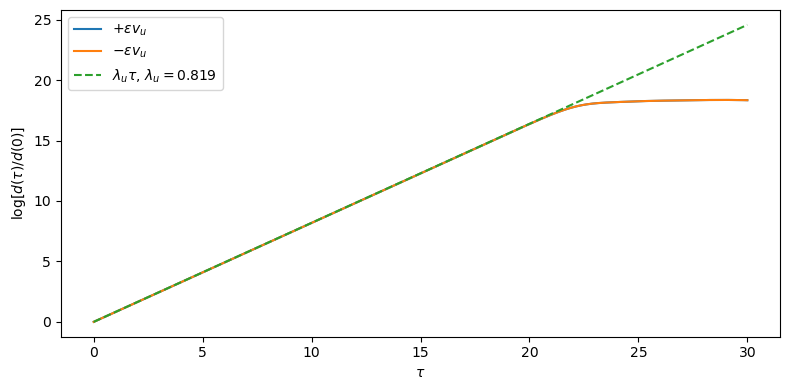

In [162]:
gamma = lam_u.real

plt.figure(figsize=(8, 4))

plt.plot(
    t_plus,
    np.log(d_plus / d_plus[0]),
    label=r"$+\epsilon v_u$",
)

plt.plot(
    t_minus,
    np.log(d_minus / d_minus[0]),
    label=r"$-\epsilon v_u$",
)

plt.plot(
    t_plus,
    gamma * t_plus,
    "--",
    label=fr"$\lambda_u\tau$, $\lambda_u={gamma:.3f}$",
)

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\log[d(\tau)/d(0)]$")
plt.legend()
plt.tight_layout()
plt.show()

In [163]:
fit_mask = (
    (t_plus > 1.0)
    & (t_plus < 12.0)
    & np.isfinite(d_plus)
    & (d_plus > 0)
)

slope, intercept = np.polyfit(
    t_plus[fit_mask],
    np.log(d_plus[fit_mask] / d_plus[0]),
    1,
)

print("Jacobian prediction =", gamma)
print("measured slope       =", slope)
print("relative error       =", abs(slope - gamma) / abs(gamma))

Jacobian prediction = 0.8189799326942324
measured slope       = 0.8189799320004841
relative error       = 8.470882537524947e-10


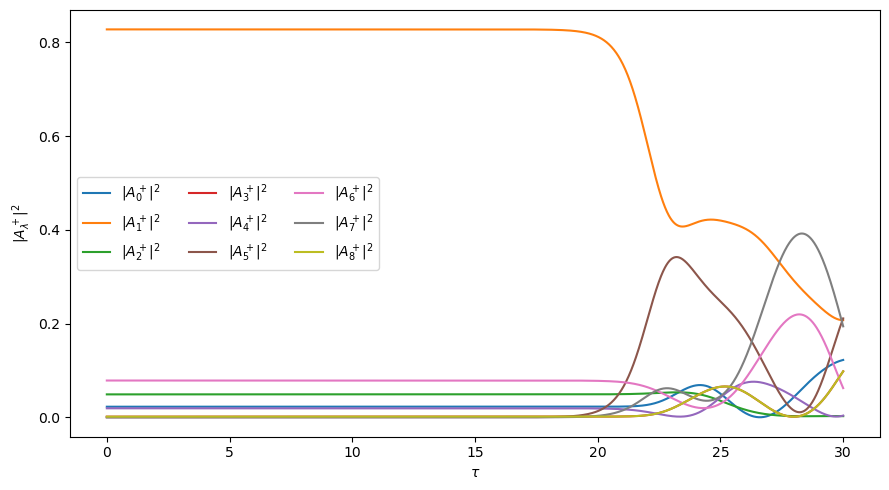

In [164]:
powers_plus  = np.abs(A_plus)**2
powers_minus = np.abs(A_minus)**2

fig, ax = plt.subplots(figsize=(9, 5))

for j in range(powers_plus.shape[1]):
    ax.plot(
        t_plus,
        powers_plus[:, j],
        label=fr"$|A^+_{j}|^2$",
    )

ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$|A^+_\lambda|^2$")
ax.legend(ncol=3)
fig.tight_layout()
plt.show()

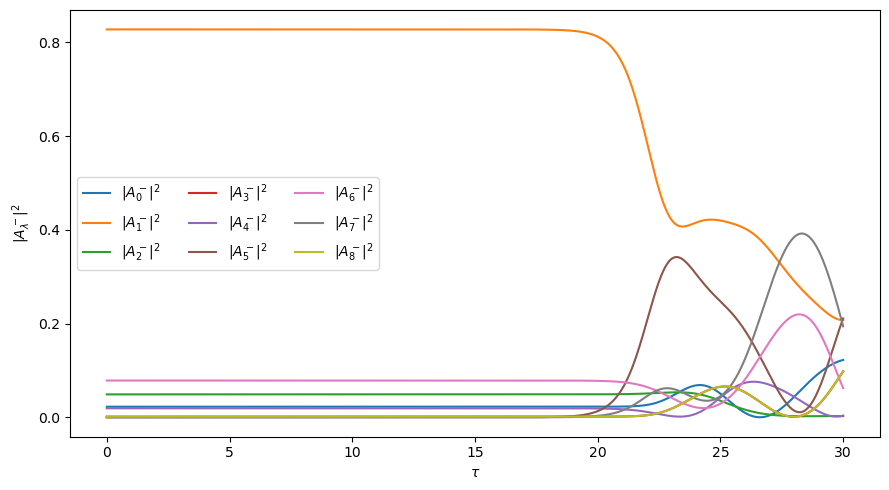

In [165]:
fig, ax = plt.subplots(figsize=(9, 5))

for j in range(powers_minus.shape[1]):
    ax.plot(
        t_minus,
        powers_minus[:, j],
        label=fr"$|A^-_{j}|^2$",
    )

ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$|A^-_\lambda|^2$")
ax.legend(ncol=3)
fig.tight_layout()
plt.show()

# Kinetic Eqn

In [166]:



def kinetic_collision(n, W):
    """
    Four-wave kinetic collision operator.

    W[l,i,j,k] contains
        |C[l,i,j,k]|^2 * resonance weight

    Returns Q_l[n], without the overall 4*pi*eps^4 factor.
    """
    n = np.asarray(n, dtype=float)

    nl = n[:, None, None, None]
    ni = n[None, :, None, None]
    nj = n[None, None, :, None]
    nk = n[None, None, None, :]

    # Algebraically identical to
    #
    # nl*ni*nj*nk * (1/nl + 1/nk - 1/ni - 1/nj)
    #
    # but nonsingular when some n's vanish.
    bracket = (
        ni * nj * nk
        + nl * ni * nj
        - nl * nj * nk
        - nl * ni * nk
    )

    return np.sum(
        W * bracket,
        axis=(1, 2, 3),
    )

In [167]:
W = np.abs(C_Ham)**2

In [168]:
def kinetic_rhs(T, n, W):
    return kinetic_collision(n, W)

In [169]:
n0 = np.abs(A0_balanced)**2
n0 = n0 / np.sum(n0)

print("N0 =", np.sum(n0))
print(n0)

N0 = 1.0
[0.4 0.3 0.2 0.1 0.  0.  0.  0.  0. ]


In [170]:
from scipy.integrate import solve_ivp


def integrate_kinetic(
    n0,
    W,
    Tmax=500.0,
    npts=2000,
    rtol=1e-10,
    atol=1e-12,
):
    T_eval = np.linspace(
        0.0,
        Tmax,
        npts,
    )

    sol = solve_ivp(
        lambda T, n: kinetic_rhs(T, n, W),
        (0.0, Tmax),
        np.asarray(n0, dtype=float),
        t_eval=T_eval,
        method="DOP853",
        rtol=rtol,
        atol=atol,
    )

    if not sol.success:
        print(sol.message)

    return sol


sol_kin = integrate_kinetic(
    n0,
    W,
    Tmax=500.0,
)

In [171]:
Tkin = sol_kin.t
nkin = sol_kin.y.T

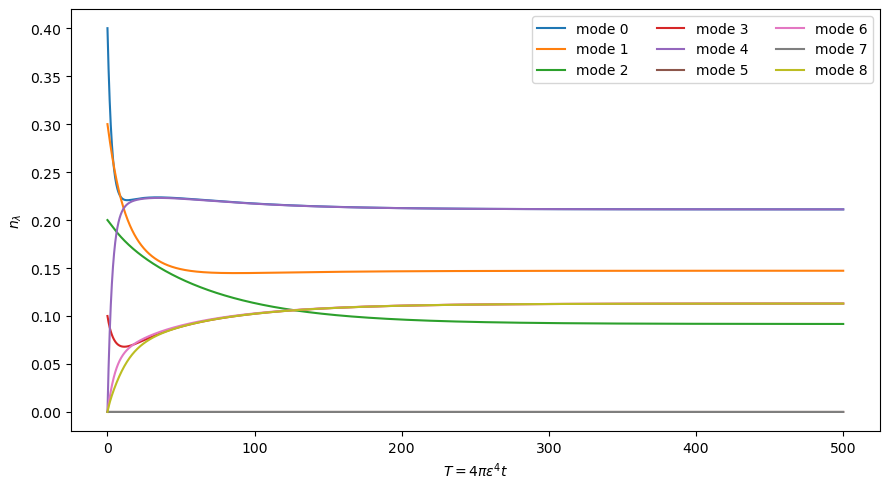

In [172]:

plt.figure(figsize=(9, 5))

for l in range(nkin.shape[1]):
    plt.plot(
        Tkin,
        nkin[:, l],
        label=f"mode {l}",
    )

plt.xlabel(r"$T=4\pi\epsilon^4 t$")
plt.ylabel(r"$n_\lambda$")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

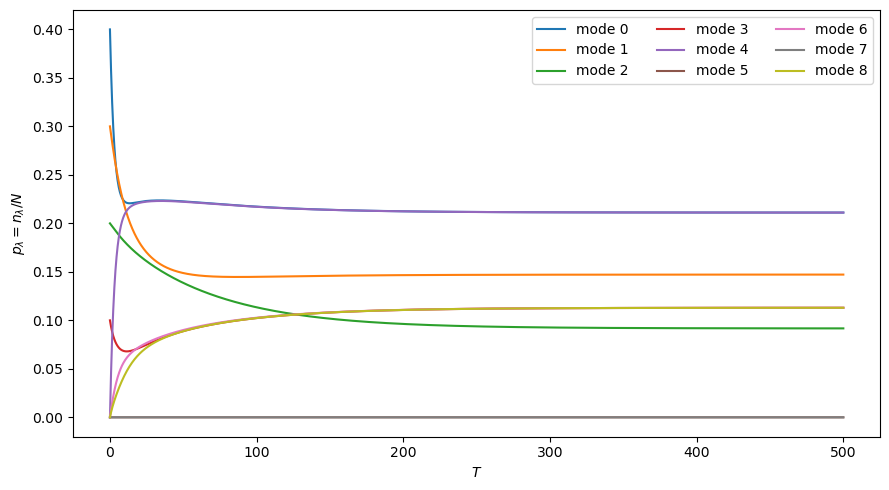

In [173]:
Nkin = np.sum(nkin, axis=1)

pkin = nkin / Nkin[:, None]

plt.figure(figsize=(9, 5))

for l in range(pkin.shape[1]):
    plt.plot(
        Tkin,
        pkin[:, l],
        label=f"mode {l}",
    )

plt.xlabel(r"$T$")
plt.ylabel(r"$p_\lambda=n_\lambda/N$")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

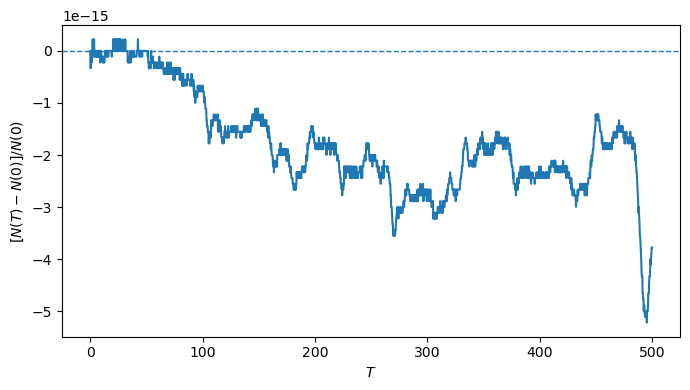

relative N drift = -3.774758283725532e-15


In [174]:
Nkin = np.sum(nkin, axis=1)

plt.figure(figsize=(7, 4))
plt.plot(
    Tkin,
    (Nkin - Nkin[0]) / Nkin[0],
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel(r"$T$")
plt.ylabel(r"$[N(T)-N(0)]/N(0)$")
plt.tight_layout()
plt.show()

print(
    "relative N drift =",
    (Nkin[-1] - Nkin[0]) / Nkin[0],
)

In [175]:
omega_R = np.real(omega_arr)

Ekin = nkin @ omega_R

print(
    "relative E drift =",
    (Ekin[-1] - Ekin[0]) / Ekin[0],
)

relative E drift = -3.885780586188048e-15


In [176]:
rng = np.random.default_rng(123)

ntest = rng.uniform(
    0.1,
    1.0,
    size=W.shape[0],
)

Qtest = kinetic_collision(
    ntest,
    W,
)

print("sum Q =", np.sum(Qtest))

sum Q = 5.551115123125783e-16


In [177]:
print(
    "energy collision sum =",
    np.dot(
        np.real(omega_arr),
        Qtest,
    )
)

energy collision sum = 1.4519409284881682e-16


In [178]:
n_final = nkin[-1]

Q_final = kinetic_collision(
    n_final,
    W,
)

print("||C[n_final]|| =",
      np.linalg.norm(Q_final))

print("max |C_lambda| =",
      np.max(np.abs(Q_final)))

||C[n_final]|| = 9.20726612630875e-07
max |C_lambda| = 6.746307761816073e-07
